# Coffee ML

Analysing James Hoffman's Great American Taste Test with Cometeer dataset (https://bit.ly/gacttCSV)

Github repo: https://github.com/AneteZepa/Coffee-ML

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf



In [3]:
from google.colab import files

uploaded = files.upload()


Saving GACTT_RESULTS_ANONYMIZED_v2.csv to GACTT_RESULTS_ANONYMIZED_v2.csv


In [4]:
import io

df = pd.read_csv(io.BytesIO(uploaded['GACTT_RESULTS_ANONYMIZED_v2.csv']))
#print(df)

## Freeform exploration of the data

This section jsut does the basic understanding of data, feel free to just add anything that views or summarizes the data without modifying the df.


In [5]:
# Alternative

# url = 'copied_raw_github_link'
# df = pd.read_csv(url)

In [6]:
df.describe()


,What kind of flavorings do you add?,What kind of flavorings do you add? (Vanilla Syrup),What kind of flavorings do you add? (Caramel Syrup),What kind of flavorings do you add? (Hazelnut Syrup),What kind of flavorings do you add? (Cinnamon (Ground or Stick)),What kind of flavorings do you add? (Peppermint Syrup),What kind of flavorings do you add? (Other),What other flavoring do you use?,"Lastly, how would you rate your own coffee expertise?",Coffee A - Bitterness,...,Coffee A - Personal Preference,Coffee B - Bitterness,Coffee B - Acidity,Coffee B - Personal Preference,Coffee C - Bitterness,Coffee C - Acidity,Coffee C - Personal Preference,Coffee D - Bitterness,Coffee D - Acidity,Coffee D - Personal Preference
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3938.000000,3798.000000,...,3789.000000,3780.000000,3767.000000,3773.000000,3764.000000,3751.000000,3766.000000,3767.000000,3765.000000,3764.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.693499,2.141127,...,3.310900,3.013228,2.223786,3.068646,3.071998,2.366836,3.064790,2.162729,3.858167,3.375930
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.948867,0.947163,...,1.185953,0.992875,0.865389,1.113546,0.999267,0.921048,1.128431,1.081546,1.007973,1.452504
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,2.000000,...,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,3.000000,2.000000,4.000000,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,3.000000,5.000000,5.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
df.count()

,0
Submission ID,4042
What is your age?,4011
How many cups of coffee do you typically drink per day?,3949
Where do you typically drink coffee?,3972
Where do you typically drink coffee? (At home),3975
...,...
Ethnicity/Race,3418
Ethnicity/Race (please specify),105
Employment Status,3419
Number of Children,856


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4042 entries, 0 to 4041
Columns: 113 entries, Submission ID to Political Affiliation
dtypes: float64(21), object(92)
memory usage: 3.5+ MB


In [9]:
df.shape

(4042, 113)

## Column by column analysis to understand the data.

This looks at columns - what we have as values

This section also is for only viewing or summarizing or displaying data.


In [ ]:
cols = df.columns

print(cols)

In [ ]:
df.tail()

In [ ]:
age_groups = df['What is your age?'].unique()
age_groups

In [ ]:
age_g_count = df['What is your age?'].value_counts()
age_g_count

In [ ]:
age_g_count.plot.pie(y='What is your age?')

In [ ]:
gender_groups = df['Gender'].unique()
gender_g_count = df['Gender'].value_counts()
gender_g_count.plot.pie(y='Gender')

In [ ]:
cup_of_coffee_groups = df['How many cups of coffee do you typically drink per day?'].unique()
cup_of_coffee_count = df['How many cups of coffee do you typically drink per day?'].value_counts()
cup_of_coffee_count.plot.pie(y='How many cups of coffee do you typically drink per day?')

In [ ]:
gender_groups = df['Where do you typically drink coffee?'].unique()
gender_g_count = df['Where do you typically drink coffee?'].value_counts()
gender_g_count.plot.pie(y='Where do you typically drink coffee?')

In [ ]:
gender_groups = df['How do you brew coffee at home?'].unique()
gender_g_count = df['How do you brew coffee at home?'].value_counts()
gender_g_count.plot.pie(y='How do you brew coffee at home?')

## Gemini analysis from raw data (LLM)

Okay, let's break down the insights from this coffee survey data.

Initial Observation: There are quite a few rows with missing data, especially for the coffee tasting ratings (Coffees A-D) and some demographic details. This analysis will focus on the data that is present.

Respondent Demographics
Age: The largest group of respondents falls into the 25-34 years old category, followed closely by 35-44 years old. There are also significant numbers from the 18-24 and 45-54 groups. Fewer respondents are under 18 or over 55.

Gender: Based on the responses where gender was provided (excluding blanks and "Prefer not to say"), Males slightly outnumber Females. A small number identified as Non-binary or specified another identity.

Education: The most common education level is a Bachelor's degree, followed by a Master's degree. Some college/associate's degrees are also well-represented. Doctorate/professional degrees, high school graduates, and less than high school are less common.

Employment: The vast majority of respondents are Employed full-time. Smaller groups are students, employed part-time, unemployed, retired, or homemakers.

Ethnicity/Race: The predominant ethnicity reported is White/Caucasian. Asian/Pacific Islander and Hispanic/Latino are the next most common groups, though much smaller. Several respondents indicated "Other" or "Mixed". (Note: Specific counts depend heavily on how "Other" responses are interpreted and the significant number of blanks).

Political Affiliation: Democrats form the largest group, followed by Independents and those with No affiliation. Republicans represent a smaller portion of the respondents who answered this question.

Coffee Consumption Habits
Frequency: The most common consumption frequencies reported are 1 cup and 2 cups per day. "3 cups" and "More than 4 cups" are also frequent, while "Less than 1" is less common.

Location: At home is overwhelmingly the most popular place to drink coffee, reported by a vast majority of respondents who answered. At the office is the second most common location. Drinking at a cafe and on the go are also popular but less frequent than at home or the office.

Purchasing (On the Go): When buying coffee out:

Local cafes and Specialty coffee shops are popular choices.

National chains (like Starbucks/Dunkin') are also frequently visited.

Drive-thrus are a common purchasing point.

Purchasing from Deli/supermarkets is less common.

Preparation and Preferences
Home Brewing Methods:

Pour over is the most popular single brewing method reported among those brewing at home.

Espresso machines and standard Coffee brewing machines (e.g., Mr. Coffee) are also very common.

French press, Cold brew, and Pod/capsule machines (Keurig/Nespresso) are used by a significant number of respondents.

Methods like Aeropress, Moka Pot, Instant Coffee, and Coffee Extract are used but are less prevalent.

Favorite Drinks: Pourover is the most frequently cited favorite drink, followed by Latte, Regular drip coffee, Espresso, Iced coffee, and Cappuccino. Cold brew and Americano are also popular choices.

Additions:

A majority of respondents add something to their coffee.

Drinking coffee black is also very common.

Milk/dairy alternative/creamer is the most common addition.

Sugar/sweetener is the next most frequent addition.

Flavor syrup is added less often.

Dairy/Alternatives: Whole milk is the most popular dairy addition, followed by Half and half and Oat milk. Skim milk, Almond milk, Coffee creamer (flavored and unflavored), and Soy milk are used less frequently.

Sweeteners: Granulated Sugar is the most common sweetener, with Raw Sugar (Turbinado) and Brown Sugar also being used. Artificial sweeteners, Honey, Stevia, and Maple Syrup appear less often.

Stated Preferences (Before Tasting):

Taste profiles like Fruity, Chocolatey, and Nutty appear to be the most preferred general descriptions. Full Bodied and Bright are also commonly chosen.

Strength preference leans towards Somewhat strong and Medium, though Very strong is also selected often.

Light and Medium roasts are the most preferred roast levels.

The overwhelming majority prefer Full caffeine.

Self-Rated Expertise: Most respondents rate their coffee expertise somewhere in the middle to upper-middle range (around 6, 7, or 8 on a scale likely up to 10). Fewer rate themselves as novices (1-3) or top experts (9-10).

Tasting Results (For those who participated)
Overall Favorite: Coffee D was the most frequently chosen overall favorite coffee in the tasting, followed by Coffee A. Coffee B and C were chosen less often as the overall favorite.

Pairwise Preferences:

Between A, B, and C: Coffee A and Coffee C were preferred more often than Coffee B.

Between A and D: Coffee D was preferred over Coffee A by a noticeable margin.

Individual Coffee Ratings (Averages based on those who rated): Note: Averages can be skewed by outliers and missing data, but provide a general sense.

Coffee A: Generally moderate bitterness, moderate-to-high acidity, relatively high preference. Often described with fruity/bright notes (apple, citrus).

Coffee B: Often rated higher in bitterness, lower in acidity, and generally lower in preference. Notes often include chocolatey, nutty, or classic/diner coffee descriptions.

Coffee C: Bitterness and acidity ratings vary, preference generally moderate to low. Notes sometimes mention chocolate, nuts, or being balanced but perhaps unremarkable.

Coffee D: Generally low bitterness, high acidity, and highest average preference. Overwhelmingly associated with strong fruity notes (berries, blueberry, etc.), often described as complex or bright.

Motivations and Spending
Reasons for Drinking: The most common reasons cited are "It tastes good" and "I need the caffeine". "I need the ritual" is also a very significant factor. "It makes me go to the bathroom" is a less common, but still mentioned, reason.

Taste Appreciation: The vast majority like the taste of coffee.

Spending:

Monthly spending varies, but common ranges are $20-$40 and $40-$60. Significant groups also spend <$20 or >$100.

Spending on equipment in the past 5 years shows a wide distribution, with $100-$300, $300-$500, $500-$1000, and More than $1,000 all being common responses, suggesting a mix of casual users and serious hobbyists.

Value Perception:

Respondents are split on whether they get good value at a cafe, with slightly more saying No or being unsure than Yes.

A strong majority feel they get good value from their coffee equipment.

Price Sensitivity: The most common answers for the most ever paid for a cup are in the $6-$10 range, while the most willing to pay often falls in the $8-$10 or $10-$15 range, though many would pay more ($15-$20, >$20).

Potential Relationships & Key Takeaways
Home Brewing Dominance: Coffee is primarily consumed and brewed at home.

Method Diversity: While pour-over is popular, a wide variety of brewing methods are used, indicating diverse preferences and investment levels in home brewing. Pod machines are common but perhaps less so than pour-over or espresso among this group.

Black Coffee is Popular, but Additions Rule: While many drink coffee black, adding milk/alternatives or sweeteners is more common overall. Oat milk shows significant popularity as a dairy alternative.

Preference for Lighter Roasts & Fruity Notes: Stated preferences and the tasting results (favoring A and particularly D) suggest this group leans towards lighter roasts with brighter, fruitier, and more acidic profiles (often associated with "third wave" coffee). Coffee D, often described with intense fruit notes, was the clear favorite in the tasting.

Expertise & Method Link: Higher self-rated expertise likely correlates with methods like Pour over and Espresso (though this needs formal analysis to confirm).

Spending Divide: There's a clear segment of respondents willing to spend significantly ($500+) on home equipment, aligning with the popularity of methods like espresso and pour-over which can require more investment.

Value Equation: People generally feel better about the value of their equipment investment than the cost of cafe coffee.

Motivation Mix: Taste, caffeine, and ritual are all strong drivers for coffee consumption in this group.

This dataset provides a snapshot of a group seemingly engaged with coffee, leaning towards modern preparation methods and flavor profiles, with a strong emphasis on home consumption.


## Step 0: Understadning the data

**This initial step doesn't change the data yet. Its purpose is purely exploratory:**


*   Loads the Data: Gets the CSV file into a Pandas DataFrame.
*   Peeks at the Content: Shows the first few rows (.head()) so you can see column names and example values.
*   Checks Structure & Types: Uses .info() to list all columns, their data types (like number, text, boolean), and how many non-missing values they have. This immediately highlights columns with many missing entries.
*  Summarizes Numerics: .describe() gives basic stats (count, mean, min, max, etc.) for columns Pandas recognizes as numbers (though be careful, survey ratings might be treated as numbers here). Including include='all' gives info on text columns too (like unique values, most frequent answer).
*  Quantifies Missing Data: Calculates the exact percentage of missing values for every single column and sorts them. This is crucial for deciding which columns might be problematic or need special handling.
*  Identifies Multi-Selects (Heuristically): Tries to guess which questions allowed multiple answers by looking for columns followed by related sub-columns in parentheses (e.g., "Where do you typically drink coffee?" followed by "Where do you typically drink coffee? (At home)"). This helps plan how to combine these later.

In [10]:
try:
    # This line assumes you've uploaded the file in an environment like Google Colab
    # and 'uploaded' is a dictionary where keys are filenames and values are file content bytes.
    # Replace 'GACTT_RESULTS_ANONYMIZED_v2.csv' if your filename is different.
    df = pd.read_csv(io.BytesIO(uploaded['GACTT_RESULTS_ANONYMIZED_v2.csv']))
    print("Successfully loaded data.")
except NameError:
    print("Error: 'uploaded' variable not found. Make sure you've uploaded the file.")
    print("Attempting to load directly (replace 'GACTT_RESULTS_ANONYMIZED_v2.csv' if needed)...")
    try:
        df = pd.read_csv('GACTT_RESULTS_ANONYMIZED_v2.csv')
        print("Successfully loaded data from local file.")
    except FileNotFoundError:
        print("Error: Could not find 'GACTT_RESULTS_ANONYMIZED_v2.csv'. Please ensure the file is in the correct directory or provide the full path.")
        df = pd.DataFrame() # Create an empty DataFrame to avoid further errors
except KeyError:
    print(f"Error: File 'GACTT_RESULTS_ANONYMIZED_v2.csv' not found in uploaded files.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors


if not df.empty:
    print("\n--- Initial Data Overview ---")

    # 1. Display the first few rows to see the data format
    print("\n1. First 5 Rows (Head):")
    print(df.head())

    # 2. Get a concise summary of the dataframe (column names, non-null counts, dtypes)
    print("\n2. Dataframe Info:")
    df.info()

    # 3. Get basic descriptive statistics for numerical columns (if any interpret correctly)
    print("\n3. Descriptive Statistics (Numerical Columns):")
    # Include all columns for a broader overview,object columns will show counts, unique, top, freq
    print(df.describe(include='all'))

    # 4. Check the dimensions of the dataframe (rows, columns)
    print(f"\n4. Dataframe Shape: {df.shape[0]} rows, {df.shape[1]} columns")

    # 5. Calculate and display the percentage of missing values for each column
    print("\n5. Missing Value Percentage per Column:")
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    print(missing_percentage.sort_values(ascending=False))

    # 6. Identify potential multi-select columns (based on naming convention)
    #    Looks for columns that might be boolean flags for a preceding question.
    print("\n6. Potential Multi-Select Base Questions (Heuristic):")
    potential_multi_select_bases = []
    cols = df.columns
    for i, col in enumerate(cols):
        # Check if the next column name starts with the current column name + ' ('
        if i + 1 < len(cols) and cols[i+1].startswith(col + ' ('):
             if '?' in col: # Check if it looks like a question
                 potential_multi_select_bases.append(col)

    print(f"Found {len(potential_multi_select_bases)} potential base questions for multi-select answers:")
    for base in potential_multi_select_bases:
        print(f"- {base}")

    print("\n--- End of Step 0 ---")
else:
    print("\nDataFrame is empty. Cannot perform analysis.")

Successfully loaded data.

--- Initial Data Overview ---

1. First 5 Rows (Head):
  Submission ID What is your age?  \
0        gMR29l   18-24 years old   
1        BkPN0e   25-34 years old   
2        W5G8jj   25-34 years old   
3        4xWgGr   35-44 years old   
4        QD27Q8   25-34 years old   

  How many cups of coffee do you typically drink per day?  \
0                                                NaN        
1                                                NaN        
2                                                NaN        
3                                                NaN        
4                                                NaN        

  Where do you typically drink coffee?  \
0                                  NaN   
1                                  NaN   
2                                  NaN   
3                                  NaN   
4                                  NaN   

  Where do you typically drink coffee? (At home)  \
0                      

## Step 1a: Data cleaning (classic)


**This "Classic Cleaning" script performs straightforward, common data cleaning tasks:**

* Removes Empty Submissions: It gets rid of rows where the respondent likely didn't answer any questions beyond providing their ID. This cleans out fundamentally incomplete entries.
* Drops Unusable Columns: It identifies and removes columns that contain no data at all (100% missing) as they offer no analytical value. It also optionally removes columns that are almost empty (e.g., more than 95% missing), simplifying the dataset by removing sparse information that's hard to analyze reliably.
* Standardizes Multi-Select Booleans: For the columns that represent sub-options of multi-select questions (like "Drink coffee? (At home)"), it converts any missing values (NaN) to False. This assumes that if a box wasn't checked (leading to a missing value), it means the respondent didn't select that specific option. It also ensures these columns consistently use boolean (True/False) values.
* Saves the Result: The modified data is saved into a new CSV file (coffee_data_cleaned_classic.csv), preserving the original data and providing a clean starting point for basic analysis.




*Note:*

*FutureWarnings where ignored for this moment, this might need to be changed later on:*


```
FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

df_cleaned_a[col].fillna(False, inplace=True)

/tmp/ipython-input-3615567716.py:85: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.

The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.
```




In [11]:
import pandas as pd
import numpy as np
import io
import re
import warnings # Import the warnings library

# --- Step 1.a: Classic Data Cleaning (Suppressing Warnings) ---

# Assume 'df' is the DataFrame loaded in Step 0
if not df.empty:
    print(f"Starting cleaning with {df.shape[0]} rows and {df.shape[1]} columns.")

    # --- 1.a.1: Remove Rows with Almost No Data ---
    original_row_count = len(df)
    df_cleaned_a = df.dropna(subset=df.columns[1:], how='all').copy() # Use .copy() explicitly
    rows_dropped = original_row_count - len(df_cleaned_a)
    print(f"\n1.a.1: Removed {rows_dropped} rows that had missing values in all columns except Submission ID.")
    print(f"        Current shape: {df_cleaned_a.shape}")

    # --- 1.a.2: Drop Columns with Excessive Missing Values ---
    missing_percentage_cleaned = (df_cleaned_a.isnull().sum() / len(df_cleaned_a)) * 100

    cols_to_drop_100 = missing_percentage_cleaned[missing_percentage_cleaned == 100].index.tolist()
    if cols_to_drop_100:
        df_cleaned_a.drop(columns=cols_to_drop_100, inplace=True)
        print(f"\n1.a.2: Dropped {len(cols_to_drop_100)} columns with 100% missing values:")
        if len(cols_to_drop_100) > 5:
             print(f"         - {cols_to_drop_100[0]}")
             print(f"         - ... ({len(cols_to_drop_100) - 2} more) ...")
             print(f"         - {cols_to_drop_100[-1]}")
        else:
            for col in cols_to_drop_100:
                print(f"         - {col}")

    threshold = 95.0
    cols_to_drop_high_missing = missing_percentage_cleaned[(missing_percentage_cleaned > threshold) & (missing_percentage_cleaned < 100)].index.tolist()
    if cols_to_drop_high_missing:
        df_cleaned_a.drop(columns=cols_to_drop_high_missing, inplace=True)
        print(f"\n       Dropped {len(cols_to_drop_high_missing)} additional columns with > {threshold}% missing values:")
        if len(cols_to_drop_high_missing) > 5:
             print(f"         - {cols_to_drop_high_missing[0]}")
             print(f"         - ... ({len(cols_to_drop_high_missing) - 2} more) ...")
             print(f"         - {cols_to_drop_high_missing[-1]}")
        else:
             for col in cols_to_drop_high_missing:
                 print(f"         - {col}")

    print(f"        Current shape after dropping columns: {df_cleaned_a.shape}")


    # --- 1.a.3: Handle NaNs in Multi-Select Boolean Columns (Warning Suppressed) ---
    boolean_flag_cols = [col for col in df_cleaned_a.columns if '(' in col and col.endswith(')')]
    potential_bool_cols = []
    for col in boolean_flag_cols:
        unique_vals = df_cleaned_a[col].dropna().unique()
        is_likely_bool = all(str(val).upper() in ['TRUE', 'FALSE'] for val in unique_vals)
        if is_likely_bool or len(unique_vals) == 0:
             potential_bool_cols.append(col)

    print(f"\n1.a.3: Found {len(potential_bool_cols)} potential boolean multi-select columns.")
    print("        Replacing NaN with False and ensuring boolean type (suppressing FutureWarnings).")

    # --- Start Warning Suppression ---
    warnings.simplefilter(action='ignore', category=FutureWarning)

    for col in potential_bool_cols:
        # Step 1: Map to boolean or NaN
        bool_map = {'TRUE': True, 'FALSE': False, True: True, False: False}
        processed_col = df_cleaned_a[col].apply(lambda x: bool_map.get(str(x).upper()) if pd.notna(x) and isinstance(x, str) else bool_map.get(x) if pd.notna(x) else np.nan)

        # Step 2: Fill NaN with False
        filled_col = processed_col.fillna(False)

        # Step 3: Cast to boolean
        df_cleaned_a[col] = filled_col.astype(bool)

    # --- Restore Warning Behavior ---
    warnings.simplefilter(action='default', category=FutureWarning)
    # --------------------------------

    print("        NaN replacement and type conversion completed.")

    # --- 1.a.4: Save the Cleaned Data (Classic) ---
    output_filename_a = 'coffee_data_cleaned_classic_v4.csv' # Changed filename again
    df_cleaned_a.to_csv(output_filename_a, index=False)
    print(f"\n1.a.4: Saved classically cleaned data ({df_cleaned_a.shape[0]} rows, {df_cleaned_a.shape[1]} columns) to '{output_filename_a}'")

    print("\n--- End of Step 1.a (Warnings Suppressed) ---")

else:
    print("\nDataFrame is empty. Cannot perform cleaning.")

Starting cleaning with 4042 rows and 113 columns.

1.a.1: Removed 1 rows that had missing values in all columns except Submission ID.
        Current shape: (4041, 113)

1.a.2: Dropped 8 columns with 100% missing values:
         - What kind of flavorings do you add?
         - ... (6 more) ...
         - What other flavoring do you use?

       Dropped 6 additional columns with > 95.0% missing values:
         - Where else do you purchase coffee?
         - ... (4 more) ...
         - Ethnicity/Race (please specify)
        Current shape after dropping columns: (4041, 99)

1.a.3: Found 48 potential boolean multi-select columns.
        Replacing NaN with False and ensuring boolean type (suppressing FutureWarnings).
        NaN replacement and type conversion completed.

1.a.4: Saved classically cleaned data (4041 rows, 99 columns) to 'coffee_data_cleaned_classic_v4.csv'

--- End of Step 1.a (Warnings Suppressed) ---


## Step 1b: Data Cleaning

This revised "Clever Cleaning" script prioritizes understanding preferences and habits, making a decision about the tasting data's utility:

Removes Empty Submissions: Same as before, cleans baseline entries.

Combines Multi-Select Answers: Same as the previous Step 1.b, this groups related checkbox answers into single, comma-separated columns (e.g., How do you brew coffee at home - Selections) for easier analysis.

Removes Redundant Columns: Drops the original individual checkbox columns and the base multi-select question column after combination.

Assesses & Potentially Drops Tasting Data:

It first identifies all columns related to the coffee tasting (ratings, notes, comparisons).

It calculates the percentage of respondents who provided any tasting data at all.

Crucially: If this participation rate is below a set threshold (here, 60%), it concludes the tasting data is too sparse to be reliable for general analysis within this dataset and drops all tasting-related columns. If participation is higher, it keeps the columns but notes the need to handle missing values during analysis. Based on the goal to focus on preferences if tasting data is unreliable, this script leans towards dropping these columns.

Drops Remaining Empty Columns: Removes any columns that became completely empty during the process.

Saves One Focused File: Outputs a single cleaned CSV (coffee_data_cleaned_focused.csv) that contains the demographic, habit, and preference data, potentially without the tasting columns if they were deemed too sparse. This file is optimized for analyzing the broader patterns of coffee consumption and preference within the respondent group.


In [12]:
import pandas as pd
import numpy as np
import io
import re # Regular expression library
import warnings # To suppress the FutureWarning

# Suppress the specific FutureWarning about inplace fillna on copies/downcasting
warnings.simplefilter(action='ignore', category=FutureWarning)

# --- Step 1.b: Clever Data Cleaning & Structuring (Focusing on Preferences) ---

# Assume 'df' is the original DataFrame loaded in Step 0
if not df.empty:
    print(f"Starting clever cleaning with {df.shape[0]} rows and {df.shape[1]} columns.")
    df_cleaned_b = df.copy() # Work on a copy

    # --- 1.b.1: Remove Rows with Almost No Data ---
    original_row_count = len(df_cleaned_b)
    # Keep Submission ID, check NaNs in all other columns.
    df_cleaned_b = df_cleaned_b.dropna(subset=df_cleaned_b.columns[1:], how='all').copy()
    rows_dropped = original_row_count - len(df_cleaned_b)
    print(f"\n1.b.1: Removed {rows_dropped} rows that had missing values in all columns except Submission ID.")
    print(f"        Current shape: {df_cleaned_b.shape}")

    # --- 1.b.2: Identify and Combine Multi-Select Columns ---
    print("\n1.b.2: Combining multi-select columns...")
    cols_to_drop_after_combine = []

    # Use the base questions identified in Step 0, excluding the 100% missing 'Flavorings'
    potential_multi_select_bases = [
        'Where do you typically drink coffee?',
        'How do you brew coffee at home?',
        'On the go, where do you typically purchase coffee?',
        'Do you usually add anything to your coffee?',
        'What kind of dairy do you add?',
        'What kind of sugar or sweetener do you add?',
        'Why do you drink coffee?'
    ]

    multi_select_map = {}
    all_cols = df_cleaned_b.columns.tolist()

    for base_col in potential_multi_select_bases:
        if base_col in df_cleaned_b.columns:
             options_cols = []
             for col in all_cols:
                  # Check if the column starts with the base question AND has the parenthesis format
                  if col.startswith(base_col + ' (') and col.endswith(')'):
                       options_cols.append(col)
             if options_cols: # Only add if we found corresponding option columns
                  multi_select_map[base_col] = options_cols

    processed_bases_count = 0
    for base_col, option_cols in multi_select_map.items():
        processed_bases_count += 1
        # Create a simpler name for the new combined column
        # Remove common question marks and parenthetical examples for brevity
        clean_base = re.sub(r'\s*\?$', '', base_col) # Remove trailing question mark
        clean_base = re.sub(r'\s*\(e\.g\..*\)', '', clean_base) # Remove examples like (e.g., ...)
        new_col_name = clean_base.strip() + ' - Selections'
        print(f"        Processing: '{base_col}' -> '{new_col_name}'")

        # Function to apply per row
        def combine_options(row):
            selected_options = []
            for opt_col in option_cols:
                # Extract the option name cleanly
                match = re.search(r'\((.*?)\)', opt_col)
                option_name = match.group(1).strip() if match else opt_col

                # Handle potential boolean or string 'TRUE' values reliably
                value = row[opt_col]
                is_selected = False
                if isinstance(value, str) and value.upper() == 'TRUE':
                    is_selected = True
                elif isinstance(value, bool) and value:
                     is_selected = True
                # Add other potential 'true' values if needed, e.g., 1

                if is_selected:
                    selected_options.append(option_name)

            return ', '.join(selected_options) if selected_options else np.nan

        # Apply the function row-wise
        df_cleaned_b[new_col_name] = df_cleaned_b.apply(combine_options, axis=1)

        # Mark original option columns for removal
        cols_to_drop_after_combine.extend(option_cols)

    print(f"        Processed {processed_bases_count} multi-select base questions.")

    # Mark original base question columns for removal
    for base_col in multi_select_map.keys():
         if base_col in df_cleaned_b.columns:
              cols_to_drop_after_combine.append(base_col)

    # Ensure no duplicates and columns exist before dropping
    cols_to_drop_unique = list(set(cols_to_drop_after_combine))
    cols_to_drop_existing = [col for col in cols_to_drop_unique if col in df_cleaned_b.columns]

    df_cleaned_b.drop(columns=cols_to_drop_existing, inplace=True)
    print(f"        Dropped {len(cols_to_drop_existing)} original multi-select related columns.")
    print(f"        Current shape after combining: {df_cleaned_b.shape}")

    # --- 1.b.3: Assess and Potentially Drop Tasting Columns ---
    print("\n1.b.3: Assessing tasting data completeness...")
    # Identify all columns related to the tasting section
    tasting_cols_pattern = r'Coffee [A-D] - |Between Coffee|favorite overall coffee'
    tasting_columns = [col for col in df.columns if re.search(tasting_cols_pattern, col, re.IGNORECASE)]
    # Make sure they exist in the current dataframe
    tasting_columns_present = [col for col in tasting_columns if col in df_cleaned_b.columns]

    if tasting_columns_present:
        # Calculate how many rows have AT LEAST ONE non-NaN value in any tasting column
        rows_with_tasting_data = df_cleaned_b[tasting_columns_present].dropna(how='all').shape[0]
        total_rows = df_cleaned_b.shape[0]
        participation_rate = (rows_with_tasting_data / total_rows) * 100
        print(f"        {rows_with_tasting_data} out of {total_rows} rows ({participation_rate:.2f}%) have at least one tasting entry.")

        # Decision: Drop if participation is low (e.g., < 60%)
        tasting_threshold = 60.0
        if participation_rate < tasting_threshold:
            df_cleaned_b.drop(columns=tasting_columns_present, inplace=True)
            print(f"        Participation rate below {tasting_threshold}%. Dropping {len(tasting_columns_present)} tasting-related columns to focus on preferences.")
            print(f"        Current shape: {df_cleaned_b.shape}")
        else:
            print(f"        Participation rate is {participation_rate:.2f}%. Keeping tasting columns, but be mindful of NaNs during analysis.")
    else:
        print("        No tasting columns identified in the current dataframe.")

    # --- 1.b.4: Drop Remaining 100% Missing Columns ---
    missing_percentage_final = (df_cleaned_b.isnull().sum() / len(df_cleaned_b)) * 100
    cols_to_drop_100_final = missing_percentage_final[missing_percentage_final == 100].index.tolist()

    if cols_to_drop_100_final:
        df_cleaned_b.drop(columns=cols_to_drop_100_final, inplace=True)
        print(f"\n1.b.4: Dropped {len(cols_to_drop_100_final)} remaining columns with 100% missing values.")
         # Print sparingly
        if len(cols_to_drop_100_final) > 5:
             print(f"         - {cols_to_drop_100_final[0]}")
             print(f"         - ... ({len(cols_to_drop_100_final) - 2} more) ...")
             print(f"         - {cols_to_drop_100_final[-1]}")
        else:
             for col in cols_to_drop_100_final:
                  print(f"         - {col}")
        print(f"        Current shape: {df_cleaned_b.shape}")
    else:
        print("\n1.b.4: No remaining columns found with 100% missing values.")

    # --- 1.b.5: Save the Focused Cleaned Data ---
    output_filename_b = 'coffee_data_cleaned_focused.csv'
    df_cleaned_b.to_csv(output_filename_b, index=False)
    print(f"\n1.b.5: Saved focused cleaned data ({df_cleaned_b.shape[0]} rows, {df_cleaned_b.shape[1]} columns) to '{output_filename_b}'")

    print("\n--- End of Step 1.b ---")

else:
    print("\nOriginal DataFrame is empty. Cannot perform cleaning.")

# Restore default warning behavior if needed elsewhere
# warnings.simplefilter(action='default', category=FutureWarning)

Starting clever cleaning with 4042 rows and 113 columns.

1.b.1: Removed 1 rows that had missing values in all columns except Submission ID.
        Current shape: (4041, 113)

1.b.2: Combining multi-select columns...
        Processing: 'Where do you typically drink coffee?' -> 'Where do you typically drink coffee - Selections'
        Processing: 'How do you brew coffee at home?' -> 'How do you brew coffee at home - Selections'
        Processing: 'On the go, where do you typically purchase coffee?' -> 'On the go, where do you typically purchase coffee - Selections'
        Processing: 'Do you usually add anything to your coffee?' -> 'Do you usually add anything to your coffee - Selections'
        Processing: 'What kind of dairy do you add?' -> 'What kind of dairy do you add - Selections'
        Processing: 'What kind of sugar or sweetener do you add?' -> 'What kind of sugar or sweetener do you add - Selections'
        Processing: 'Why do you drink coffee?' -> 'Why do you drink co

## Step 1.5b: Review of the free-text fields
This step is crucial for catching nuances that automated cleaning might miss.

This script will load the coffee_data_cleaned_focused.csv you just created, analyze the text-based 'Other' and 'Notes' columns, and flag potentially invalid entries for review.

Step 1.5.b: Reviewing and Flagging Text Fields
This script will:

Identify Text Columns: Automatically find columns that likely contain free-text responses (based on name and data type).

Analyze 'Other' Columns: For columns where users could specify an "Other" option, it will show the most common entries to see if any should be standardized (e.g., if many people typed "Aeropress").

Analyze Tasting Notes: For the coffee tasting notes, it will perform a simple word frequency analysis to identify the most common descriptive terms used for each coffee.

Flag Invalid Entries: It will search across all text columns for keywords like "test", "audit", "no kit", etc., and flag the corresponding rows for potential exclusion in later analysis.

In [13]:
import pandas as pd
import numpy as np
import io
import re
from collections import Counter

# --- Step 1.5.b: Review and Flag Text Fields ---

try:
    # Load the focused, cleverly cleaned dataset from Step 1.b
    df = pd.read_csv('coffee_data_cleaned_focused.csv')
    print("Successfully loaded 'coffee_data_cleaned_focused.csv'.")
    print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'coffee_data_cleaned_focused.csv' not found. Please run Step 1.b first.")
    df = pd.DataFrame()

if not df.empty:
    # --- 1.5.1: Identify Text Columns for Review ---
    # Heuristics: object dtype and/or name contains 'other', 'specify', 'notes'
    text_col_keywords = ['other', 'specify', 'notes', 'else']
    object_cols = df.select_dtypes(include=['object']).columns

    text_review_cols = [
        col for col in object_cols
        if any(keyword in col.lower() for keyword in text_col_keywords) or 'Notes' in col
    ]
    # Manually add any other text columns you want to inspect that don't fit the pattern
    # Example: text_review_cols.append('Some Other Column')

    print(f"\n--- 1.5.1: Identified {len(text_review_cols)} text columns for review ---")

    # --- 1.5.2: Analyze 'Other' and Specification Columns ---
    print("\n--- 1.5.2: Analyzing Common 'Other' Entries ---")
    other_cols = [col for col in text_review_cols if 'notes' not in col.lower()]

    for col in other_cols:
        # Get value counts, excluding NaNs
        counts = df[col].value_counts().dropna()
        if not counts.empty:
            print(f"\nTop entries for '{col}' (showing counts > 1):")
            # Filter to show more significant, repeated entries
            significant_counts = counts[counts > 1]
            if not significant_counts.empty:
                print(significant_counts)
            else:
                print("No entries appeared more than once.")

    # --- 1.5.3: Analyze Tasting Notes ---
    print("\n--- 1.5.3: Analyzing Common Words in Tasting Notes ---")
    notes_cols = [col for col in text_review_cols if 'Notes' in col]
    stop_words = set([
        'a', 'an', 'the', 'it', 'is', 'and', 'but', 'in', 'of', 'to', 'for', 'was', 'with',
        'i', 'this', 'that', 'not', 'my', 'me', 'like', 'as', 'at', 'very', 'had', 'more'
    ])

    for col in notes_cols:
        if col in df.columns:
            print(f"\nTop 15 most common words in '{col}':")
            # Combine all notes, drop NaNs, convert to a single lowercase string
            all_notes = ' '.join(df[col].dropna()).lower()

            # Clean text: remove punctuation
            all_notes_cleaned = re.sub(r'[^\w\s]', '', all_notes)

            # Tokenize and count words, excluding stop words
            words = [word for word in all_notes_cleaned.split() if word not in stop_words and not word.isdigit()]
            word_counts = Counter(words).most_common(15)

            if word_counts:
                print(pd.DataFrame(word_counts, columns=['Word', 'Count']))
            else:
                print("No notes found to analyze.")

    # --- 1.5.4: Flag Potential Invalid/Test Entries ---
    print("\n--- 1.5.4: Flagging Potential Invalid or Test Entries ---")
    search_keywords = ['test', 'audit', 'n/a', 'sample', 'no kit', 'did not have', 'don\'t have', 'irrelevant']
    # Create a regex pattern that is case-insensitive
    search_pattern = '|'.join(search_keywords)

    flagged_indices = set()

    # Search only in object columns to be efficient
    for col in df.select_dtypes(include=['object']).columns:
        # Ensure the column is treated as string and find matches
        matches = df[col].str.contains(search_pattern, case=False, na=False)
        flagged_indices.update(df[matches].index)

    if flagged_indices:
        print(f"Found {len(flagged_indices)} rows with potential invalid/test keywords.")

        # Display the flagged rows with relevant columns
        flagged_df = df.loc[list(flagged_indices)]

        # Select columns to display for context
        display_cols = ['Submission ID'] + [col for col in text_review_cols if col in flagged_df.columns]
        # Add other potentially useful columns for context if needed
        if 'What is your favorite coffee drink?' in flagged_df.columns:
            display_cols.insert(1, 'What is your favorite coffee drink?')

        print("Displaying flagged rows for review:")
        print(flagged_df[display_cols].head(10)) # Display first 10 for brevity

        # Save the IDs of flagged rows to a file for potential exclusion later
        flagged_ids = flagged_df['Submission ID'].tolist()
        with open('flagged_submission_ids.txt', 'w') as f:
            for submission_id in flagged_ids:
                f.write(f"{submission_id}\n")
        print(f"\nSaved {len(flagged_ids)} flagged Submission IDs to 'flagged_submission_ids.txt'")
    else:
        print("No rows found with invalid/test keywords.")

    print("\n--- End of Step 1.5.b ---")
else:
    print("\nDataFrame is empty. Cannot perform analysis.")


Successfully loaded 'coffee_data_cleaned_focused.csv'.
Dataset has 4041 rows and 57 columns.

--- 1.5.1: Identified 11 text columns for review ---

--- 1.5.2: Analyzing Common 'Other' Entries ---

Top entries for 'How else do you brew coffee at home?' (showing counts > 1):
How else do you brew coffee at home?
Aeropress                   297
Aeropress                    37
AeroPress                    34
aeropress                    31
Moka pot                     29
Moka Pot                     16
Clever Dripper                9
moka pot                      8
Clever dripper                6
Hario Switch                  6
Siphon                        5
Turkish                       5
Moka                          5
Clever                        5
Aeropress, Moka Pot           5
clever dripper                3
Aeropress, Moka pot           3
aero press                    3
Aeropress, MokaPot            3
Aeropress, clever             2
Aeropress, Hario Switch       2
Moka Pot, Aeropre

## Step 1.6b: Spelling standartization

In [14]:
import pandas as pd
import numpy as np
import io
import re

# --- Step 1.6.b: Standardize Text and Consolidate Categories ---

try:
    # Load the focused, cleverly cleaned dataset from Step 1.b
    df = pd.read_csv('coffee_data_cleaned_focused.csv')
    print("Successfully loaded 'coffee_data_cleaned_focused.csv'.")
    print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'coffee_data_cleaned_focused.csv' not found. Please run Step 1.b first.")
    df = pd.DataFrame()

if not df.empty:

    # --- 1.6.1: Define Standardization Rules ---
    # We'll map various spellings/casings to a single official name.
    # The key is the text to find (lowercase), the value is the official name.
    brew_method_map = {
        'aeropress': 'AeroPress',
        'aero press': 'AeroPress',
        'areopress': 'AeroPress',
        'moka pot': 'Moka Pot',
        'mokapot': 'Moka Pot',
        'mocha pot': 'Moka Pot',
        'moka': 'Moka Pot',
        'clever dripper': 'Clever Dripper',
        'clever': 'Clever Dripper',
        'hario switch': 'Hario Switch',
        'siphon': 'Siphon', # Standardize spelling/casing
        'syphon': 'Siphon',
        'turkish': 'Turkish',
        'percolator': 'Percolator',
        'phin': 'Phin',
        'immersion': 'Immersion' # General category
    }

    favorite_drink_map = {
        'flat white': 'Flat White',
        'french press': 'French Press',
        'aeropress': 'AeroPress',
        'macchiato': 'Macchiato',
        'affogato': 'Affogato',
        'miel': 'Miel',
        'breve': 'Breve',
        'cafe au lait': 'Cafe au lait'
    }

    # --- 1.6.2: Create a Reusable Standardization Function ---
    def standardize_text_entries(text, mapping):
        if pd.isna(text):
            return np.nan

        # Split entries by common delimiters like comma or slash
        items = re.split(r'[,/&]', str(text))
        standardized_items = set() # Use a set to handle duplicates automatically

        for item in items:
            cleaned_item = item.strip().lower()
            # Find a matching key in our map
            found = False
            for key, value in mapping.items():
                if key in cleaned_item:
                    standardized_items.add(value)
                    found = True
                    break # Stop after first match for this item part
            if not found and item.strip(): # If no standard term found, keep the original (capitalized)
                standardized_items.add(item.strip().title())

        if not standardized_items:
            return np.nan

        # Return a sorted, comma-separated string
        return ', '.join(sorted(list(standardized_items)))

    # --- 1.6.3: Apply Standardization and Consolidate Brew Methods ---
    print("\n--- 1.6.3: Standardizing and Consolidating Home Brew Methods ---")
    other_brew_col = 'How else do you brew coffee at home?'
    main_brew_col = 'How do you brew coffee at home - Selections'
    final_brew_col = 'All Home Brew Methods'

    # Standardize the 'Other' brew methods column first
    if other_brew_col in df.columns:
        df[other_brew_col] = df[other_brew_col].apply(lambda x: standardize_text_entries(x, brew_method_map))
        print(f"        Standardized entries in '{other_brew_col}'.")
    else:
        print(f"        Column '{other_brew_col}' not found, skipping.")

    # Combine the main selections with the standardized 'Other' selections
    def combine_all_methods(row):
        main_methods = set(str(row[main_brew_col]).split(', ')) if pd.notna(row[main_brew_col]) else set()
        other_methods = set(str(row[other_brew_col]).split(', ')) if pd.notna(row[other_brew_col]) else set()

        all_methods = main_methods.union(other_methods)
        # Remove potential empty strings if NaNs were converted to 'nan' string
        all_methods.discard('nan')
        all_methods.discard('')

        if not all_methods:
            return np.nan

        return ', '.join(sorted(list(all_methods)))

    if main_brew_col in df.columns:
        df[final_brew_col] = df.apply(combine_all_methods, axis=1)
        print(f"        Created consolidated column: '{final_brew_col}'.")

        # Drop the old columns
        cols_to_drop = [main_brew_col]
        if other_brew_col in df.columns:
            cols_to_drop.append(other_brew_col)
        df.drop(columns=cols_to_drop, inplace=True)
        print(f"        Dropped original brew method columns.")
    else:
         print(f"        Main brew column '{main_brew_col}' not found, skipping consolidation.")

    # --- 1.6.4: Standardize Other Text Columns ---
    print("\n--- 1.6.4: Standardizing 'Favorite Coffee Drink' Entries ---")
    fav_drink_col = 'Please specify what your favorite coffee drink is'
    if fav_drink_col in df.columns:
        df[fav_drink_col] = df[fav_drink_col].apply(lambda x: standardize_text_entries(x, favorite_drink_map))
        print(f"        Standardized entries in '{fav_drink_col}'.")
    else:
        print(f"        Column '{fav_drink_col}' not found, skipping.")

    print(f"\nFinal shape after standardization: {df.shape}")

    # --- 1.6.5: Save the Final Standardized Dataset ---
    output_filename = 'coffee_data_standardized.csv'
    df.to_csv(output_filename, index=False)
    print(f"\n--- 1.6.5: Saved final standardized data to '{output_filename}' ---")

else:
    print("\nDataFrame is empty. Cannot perform cleaning.")


Successfully loaded 'coffee_data_cleaned_focused.csv'.
Dataset has 4041 rows and 57 columns.

--- 1.6.3: Standardizing and Consolidating Home Brew Methods ---
        Standardized entries in 'How else do you brew coffee at home?'.
        Created consolidated column: 'All Home Brew Methods'.
        Dropped original brew method columns.

--- 1.6.4: Standardizing 'Favorite Coffee Drink' Entries ---
        Standardized entries in 'Please specify what your favorite coffee drink is'.

Final shape after standardization: (4041, 56)

--- 1.6.5: Saved final standardized data to 'coffee_data_standardized.csv' ---


## Step 1.7: Spelling standartization using NLP

We will need fuzzy strings


In [15]:
pip install thefuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.6 MB/s eta 0:00:00


In [16]:
# --- Step 1.7.b: Automated Text Standardization Suggestions ---
#
# This script uses fuzzy string matching to find and group similar text entries,
# suggesting a more complete standardization map automatically.
# You will need to install a library to run this:
# pip install thefuzz
# or
# pip install fuzzywuzzy

import pandas as pd
from collections import defaultdict
try:
    from thefuzz import fuzz
except ImportError:
    print("Module 'thefuzz' not found.")
    print("Please install it by running: pip install thefuzz")
    fuzz = None

def suggest_standardization_map(series, similarity_threshold=85):
    """
    Analyzes a pandas Series and suggests a standardization map by grouping similar strings.

    Args:
        series (pd.Series): The series containing text data to analyze.
        similarity_threshold (int): The percentage similarity (0-100) required to group items.
                                     85 is a good starting point.

    Returns:
        dict: A suggested mapping of {variant: main_term}.
    """
    if not fuzz:
        print("Fuzzywuzzy library not installed. Cannot generate suggestions.")
        return {}

    # Get unique, non-null, and non-empty entries
    unique_entries = series.dropna().unique()
    unique_entries = [entry for entry in unique_entries if str(entry).strip()]

    # Sort by frequency to make more common terms the "standard"
    unique_entries = sorted(unique_entries, key=lambda x: -series.value_counts().get(x, 0))

    clusters = defaultdict(list)

    for entry in unique_entries:
        # If this entry has already been clustered, skip it
        if any(entry in values for values in clusters.values()):
            continue

        # This entry becomes the "main" term for a new potential cluster
        main_term = entry
        clusters[main_term].append(entry) # Add itself to its cluster

        # Compare against all other entries
        for other_entry in unique_entries:
            if other_entry == main_term or any(other_entry in values for values in clusters.values()):
                continue

            # Use token_sort_ratio to handle multi-word entries that are out of order
            ratio = fuzz.token_sort_ratio(main_term.lower(), other_entry.lower())

            if ratio >= similarity_threshold:
                clusters[main_term].append(other_entry)

    # Create the suggested mapping dictionary
    suggested_map = {}
    print("\n--- Suggested Standardization Clusters ---")
    for main_term, variants in clusters.items():
        if len(variants) > 1:
            print(f"\nMain Term: '{main_term}'")
            print("  - Variants found:", ", ".join(f"'{v}'" for v in variants if v != main_term))
            for variant in variants:
                if variant.lower() != main_term.lower():
                     suggested_map[variant.lower()] = main_term

    return suggested_map

# --- Main Execution ---
try:
    # Load the focused, cleverly cleaned dataset from Step 1.b
    df = pd.read_csv('coffee_data_cleaned_focused.csv')
    print("Successfully loaded 'coffee_data_cleaned_focused.csv'.")
except FileNotFoundError:
    print("Error: 'coffee_data_cleaned_focused.csv' not found. Please run Step 1.b first.")
    df = pd.DataFrame()

if not df.empty and fuzz:
    other_brew_col = 'How else do you brew coffee at home?'
    fav_drink_col = 'Please specify what your favorite coffee drink is'

    print("\n--- Analyzing 'Other Brew Methods' ---")
    if other_brew_col in df.columns:
        suggested_brew_map = suggest_standardization_map(df[other_brew_col])
        print("\n--- Suggested `brew_method_map` dictionary (copy this into Step 1.6.b) ---")
        print("brew_method_map = {")
        for key, value in sorted(suggested_brew_map.items()):
            print(f"    '{key}': '{value}',")
        print("}")
    else:
        print(f"Column '{other_brew_col}' not found.")

    print("\n\n--- Analyzing 'Favorite Coffee Drink' ---")
    if fav_drink_col in df.columns:
        suggested_drink_map = suggest_standardization_map(df[fav_drink_col], similarity_threshold=90)
        print("\n--- Suggested `favorite_drink_map` dictionary (copy this into Step 1.6.b) ---")
        print("favorite_drink_map = {")
        for key, value in sorted(suggested_drink_map.items()):
            print(f"    '{key}': '{value}',")
        print("}")
    else:
        print(f"Column '{fav_drink_col}' not found.")

else:
    if df.empty:
        print("\nDataFrame is empty. Cannot perform analysis.")


Successfully loaded 'coffee_data_cleaned_focused.csv'.

--- Analyzing 'Other Brew Methods' ---

--- Suggested Standardization Clusters ---

Main Term: 'Aeropress'
  - Variants found: 'Aeropress ', 'AeroPress', 'aeropress', 'aero press', 'Areopress', 'Aero press', 'Aero press ', 'Aero Press', 'AeroPress ', 'aeropress ', 'Aeropresse', 'Aeropress  '

Main Term: 'Moka pot'
  - Variants found: 'Moka Pot', 'moka pot', 'Mokkapot', 'Moka pot ', 'Mokapot '

Main Term: 'Clever Dripper'
  - Variants found: 'Clever dripper', 'clever dripper', ' Clever Dripper', 'Clever Dripper '

Main Term: 'Hario Switch'
  - Variants found: 'Hario switch', 'Hario switch '

Main Term: 'Clever'
  - Variants found: 'Clever ', 'clever'

Main Term: 'Moka'
  - Variants found: 'moka', 'Mokka'

Main Term: 'Aeropress, Moka Pot'
  - Variants found: 'Aeropress, Moka pot', 'Aeropress, MokaPot', 'Moka Pot, Aeropress', 'Mokapot, Aeropress ', 'Aeropress, moka pot', 'Aeropress, moka pot.', 'Mokapot, aeropress', 'Aeropress, Mocha

## Step 1.8: Preliminary sentiment analysis and keyword extraction on the tasting notes columns

In [17]:
pip install textblob

In [18]:
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [19]:
# --- Step 1.8: Preliminary sentiment analysis and keyword extraction on the tasting notes columns ---
#
# You will need to install libraries to run this:
# pip install textblob
# python -m textblob.download_corpora

import pandas as pd
from collections import defaultdict
import re


try:
    from textblob import TextBlob
except ImportError:
    print("Module 'textblob' not found.")
    print("Please install it by running: pip install textblob")
    print("After installation, run: python -m textblob.download_corpora")
    TextBlob = None


def analyze_note_text(note_text, keywords):
    """
    Performs sentiment analysis and keyword extraction on a single text entry.
    """
    if pd.isna(note_text):
        return None, None

    text = str(note_text).lower()

    # 1. Sentiment Analysis
    sentiment_polarity = TextBlob(text).sentiment.polarity

    # 2. Keyword Extraction
    found_keywords = {keyword for keyword in keywords if keyword in text}

    return sentiment_polarity, ', '.join(sorted(list(found_keywords))) if found_keywords else None

# --- Main Execution ---
try:
    # Load the focused, cleverly cleaned dataset from Step 1.b
    df = pd.read_csv('coffee_data_cleaned_focused.csv')
    print("Successfully loaded 'coffee_data_cleaned_focused.csv'.")
except FileNotFoundError:
    print("Error: 'coffee_data_cleaned_focused.csv' not found. Please run Step 1.b first.")
    df = pd.DataFrame()

if not df.empty and fuzz and TextBlob:


    # --- Preliminary NLP on Tasting Notes ---
    print("\n\n--- Step 1.8.b: Performing NLP on Tasting Notes ---")

    # Define a list of common tasting keywords
    taste_keywords = [
        'fruity', 'apple', 'caramel', 'bright', 'citrus', 'sour', 'lemon', 'chocolate', 'acidic',
        'nutty', 'dark', 'balanced', 'bitter', 'smooth', 'earthy', 'sweet', 'berry', 'cherry',
        'floral', 'tea', 'juicy', 'body', 'heavy', 'light', 'clean', 'funky', 'fermented',
        'woody', 'spicy', 'smoky', 'burnt', 'toasted'
    ]

    notes_cols = [col for col in df.columns if 'Notes' in col]

    if not notes_cols:
        print("No tasting notes columns found to analyze.")
    else:
        print(f"Found {len(notes_cols)} notes columns. Analyzing sentiment and extracting keywords...")

        for col in notes_cols:
            sentiment_col = col.replace('Notes', 'Sentiment')
            keywords_col = col.replace('Notes', 'Keywords')

            # Apply the analysis function
            nlp_results = df[col].apply(lambda x: analyze_note_text(x, taste_keywords))

            # Assign results to new columns
            df[sentiment_col] = nlp_results.apply(lambda x: x[0])
            df[keywords_col] = nlp_results.apply(lambda x: x[1])

            print(f"  - Created '{sentiment_col}' and '{keywords_col}'")

        # Display a sample of the new columns
        print("\nSample of new NLP-derived columns:")
        nlp_cols = [col for col in df.columns if 'Sentiment' in col or 'Keywords' in col]
        print(df[['Submission ID'] + nlp_cols].dropna(subset=nlp_cols, how='all').head())

        # Save the enriched dataset
        output_filename = 'coffee_data_with_nlp.csv'
        df.to_csv(output_filename, index=False)
        print(f"\nSuccessfully saved enriched data to '{output_filename}'")

else:
    if df.empty:
        print("\nDataFrame is empty. Cannot perform analysis.")
    if not fuzz or not TextBlob:
        print("\nOne or more required libraries are missing. Please install them to proceed.")


Successfully loaded 'coffee_data_cleaned_focused.csv'.


--- Step 1.8.b: Performing NLP on Tasting Notes ---
Found 4 notes columns. Analyzing sentiment and extracting keywords...
  - Created 'Coffee A - Sentiment' and 'Coffee A - Keywords'
  - Created 'Coffee B - Sentiment' and 'Coffee B - Keywords'
  - Created 'Coffee C - Sentiment' and 'Coffee C - Keywords'
  - Created 'Coffee D - Sentiment' and 'Coffee D - Keywords'

Sample of new NLP-derived columns:
   Submission ID  Coffee A - Sentiment Coffee A - Keywords  \
14        Zd694B                 0.000                None   
52        WApbYk                 0.000              bitter   
53        eBxG20                 0.000                None   
58        LdMxB2                 0.375        light, sweet   
59        GrBOrz                 0.455       bright, juicy   

    Coffee B - Sentiment Coffee B - Keywords  Coffee C - Sentiment  \
14              0.000000                None                  0.00   
52              0.333333    

## Step 1.9: consolidation

In [20]:
# --- Step 1.9: Final Standardization and Consolidation ---
#
# This script applies the standardization rules suggested in the previous step
# to create the final, analysis-ready dataset. It loads the data enriched
# with NLP features and consolidates messy text entries.

import pandas as pd
import numpy as np
import io
import re

# --- Main Execution ---
try:
    # Load the dataset that was enriched with NLP sentiment/keywords
    df = pd.read_csv('coffee_data_with_nlp.csv')
    print("Successfully loaded 'coffee_data_with_nlp.csv'.")
    print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'coffee_data_with_nlp.csv' not found. Please run the previous step first.")
    df = pd.DataFrame()

if not df.empty:

    # --- 1.9.1: Define Final Standardization Maps ---
    # This map is built from the suggestions of the fuzzy matching script (1.7.b)
    # with manual refinements for better grouping.
    print("\n--- 1.9.1: Using refined standardization maps ---")
    brew_method_map = {
        'aeropress': 'AeroPress',
        'aero press': 'AeroPress',
        'areopress': 'AeroPress',
        'moka pot': 'Moka Pot',
        'mokapot': 'Moka Pot',
        'mocha pot': 'Moka Pot',
        'moka': 'Moka Pot',
        'clever dripper': 'Clever Dripper',
        'clever': 'Clever Dripper',
        'hario switch': 'Hario Switch',
        'siphon': 'Siphon',
        'syphone': 'Siphon',
        'turkish coffee': 'Turkish',
        'percolator': 'Percolator',
        'phin': 'Phin',
        'immersion': 'Immersion',
        'cometeer': 'Cometeer', # Standardizing from 'Cometeer!'
    }

    favorite_drink_map = {
        'flat white': 'Flat White',
        'french press': 'French Press',
        'aeropress': 'AeroPress',
        'macchiato': 'Macchiato',
        'affogato': 'Affogato',
        'miel': 'Miel',
        'breve': 'Breve',
        'cafe au lait': 'Cafe au lait',
        'cortado': 'Cortado',
        'immersion brew': 'Immersion Brew',
        'espresso tonic': 'Espresso Tonic',
        'iced late': 'Iced Latte', # Fix typo
        'tea': 'Tea'
    }

    # --- 1.9.2: Create a Reusable Standardization Function ---
    def standardize_text_entries(text, mapping):
        if pd.isna(text):
            return np.nan

        # Split entries by common delimiters
        items = re.split(r'[,/&;]|\s+and\s+', str(text))
        standardized_items = set()

        for item in items:
            cleaned_item = item.strip().lower()
            found = False
            # Check for direct matches or if the key is contained in the item
            for key, value in mapping.items():
                if key in cleaned_item:
                    standardized_items.add(value)
                    found = True
            # If no standard term is found, keep the original (properly capitalized)
            if not found and cleaned_item:
                standardized_items.add(cleaned_item.title())

        if not standardized_items:
            return np.nan

        return ', '.join(sorted(list(standardized_items)))

    # --- 1.9.3: Apply Standardization and Consolidate Brew Methods ---
    print("\n--- 1.9.3: Standardizing and Consolidating Home Brew Methods ---")
    other_brew_col = 'How else do you brew coffee at home?'
    main_brew_col = 'How do you brew coffee at home - Selections'
    final_brew_col = 'All Home Brew Methods'

    # Standardize the 'Other' brew methods column
    if other_brew_col in df.columns:
        df[other_brew_col] = df[other_brew_col].apply(lambda x: standardize_text_entries(x, brew_method_map))
        print(f"        Standardized entries in '{other_brew_col}'.")
    else:
        print(f"        Column '{other_brew_col}' not found, skipping.")

    # Combine the main selections with the standardized 'Other' selections
    def combine_all_methods(row):
        # Use set to automatically handle duplicates
        all_methods = set()
        if main_brew_col in row and pd.notna(row[main_brew_col]):
            all_methods.update(item.strip() for item in str(row[main_brew_col]).split(','))
        if other_brew_col in row and pd.notna(row[other_brew_col]):
            all_methods.update(item.strip() for item in str(row[other_brew_col]).split(','))

        # Remove any empty strings that might have resulted from splitting
        all_methods.discard('')

        if not all_methods:
            return np.nan
        return ', '.join(sorted(list(all_methods)))

    if main_brew_col in df.columns:
        df[final_brew_col] = df.apply(combine_all_methods, axis=1)
        print(f"        Created consolidated column: '{final_brew_col}'.")

        # Drop the old, now-redundant columns
        cols_to_drop = [main_brew_col]
        if other_brew_col in df.columns:
            cols_to_drop.append(other_brew_col)
        df.drop(columns=cols_to_drop, inplace=True)
        print(f"        Dropped original brew method columns.")

        # Display a sample of the new consolidated column
        print("\nSample of new 'All Home Brew Methods' column:")
        print(df[final_brew_col].value_counts().head(10))
    else:
         print(f"        Main brew column '{main_brew_col}' not found, skipping consolidation.")

    # --- 1.9.4: Standardize Other Text Columns ---
    print("\n--- 1.9.4: Standardizing 'Favorite Coffee Drink' Entries ---")
    fav_drink_col = 'Please specify what your favorite coffee drink is'
    if fav_drink_col in df.columns:
        df[fav_drink_col] = df[fav_drink_col].apply(lambda x: standardize_text_entries(x, favorite_drink_map))
        print(f"        Standardized entries in '{fav_drink_col}'.")
    else:
        print(f"        Column '{fav_drink_col}' not found, skipping.")

    print(f"\nFinal shape after standardization: {df.shape}")

    # --- 1.9.5: Save the Final Analysis-Ready Dataset ---
    output_filename = 'coffee_data_final_analysis_ready.csv'
    df.to_csv(output_filename, index=False)
    print(f"\n--- 1.9.5: Saved final analysis-ready data to '{output_filename}' ---")

else:
    print("\nDataFrame is empty. Cannot perform cleaning.")



Successfully loaded 'coffee_data_with_nlp.csv'.
Dataset has 4041 rows and 65 columns.

--- 1.9.1: Using refined standardization maps ---

--- 1.9.3: Standardizing and Consolidating Home Brew Methods ---
        Standardized entries in 'How else do you brew coffee at home?'.
        Created consolidated column: 'All Home Brew Methods'.
        Dropped original brew method columns.

Sample of new 'All Home Brew Methods' column:
All Home Brew Methods
Pour over                                             574
Espresso, Pour over                                   476
Espresso                                              292
Coffee brewing machine (e.g. Mr. Coffee               204
AeroPress, Other                                      139
French press, Pour over                                97
Espresso, French press, Pour over                      92
Coffee brewing machine (e.g. Mr. Coffee, Pour over     92
Pod/capsule machine (e.g. Keurig/Nespresso             80
Cold brew, Espresso, Pour 

## Step 2: Exploratory Data Analysis (EDA) & Descriptive Statistics from 1b and onwards

This comprehensive script will load the final cleaned dataset, coffee_data_final_analysis_ready.csv, and generate a series of visualizations to explore the distributions of demographics, consumption habits, preferences, and the NLP features we created. It will also handle the analysis of the multi-select columns by breaking them down into individual counts.




Successfully loaded 'coffee_data_final_analysis_ready.csv'.
Created 'plots' directory to save images.

--- 2.1: Analyzing Demographics ---
        Plot saved to 'plots/age_distribution.png'


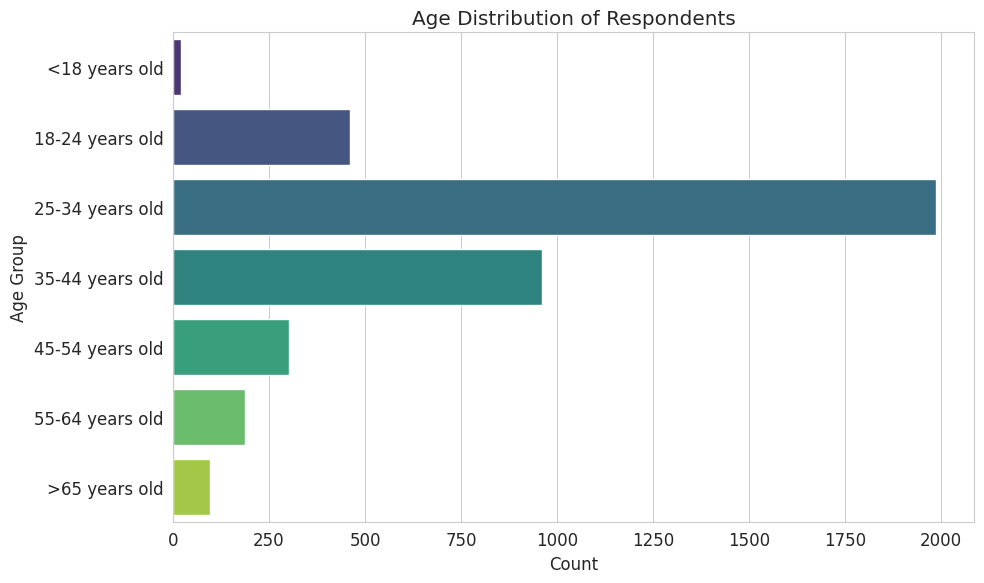

        Plot saved to 'plots/education_level.png'


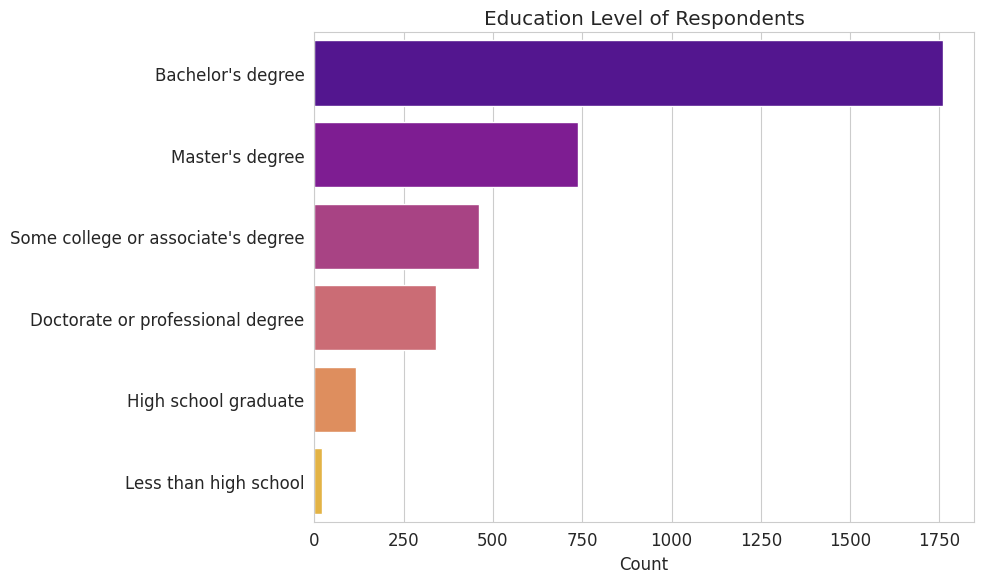


--- 2.2: Analyzing Consumption Habits ---
        Plot saved to 'plots/daily_consumption.png'


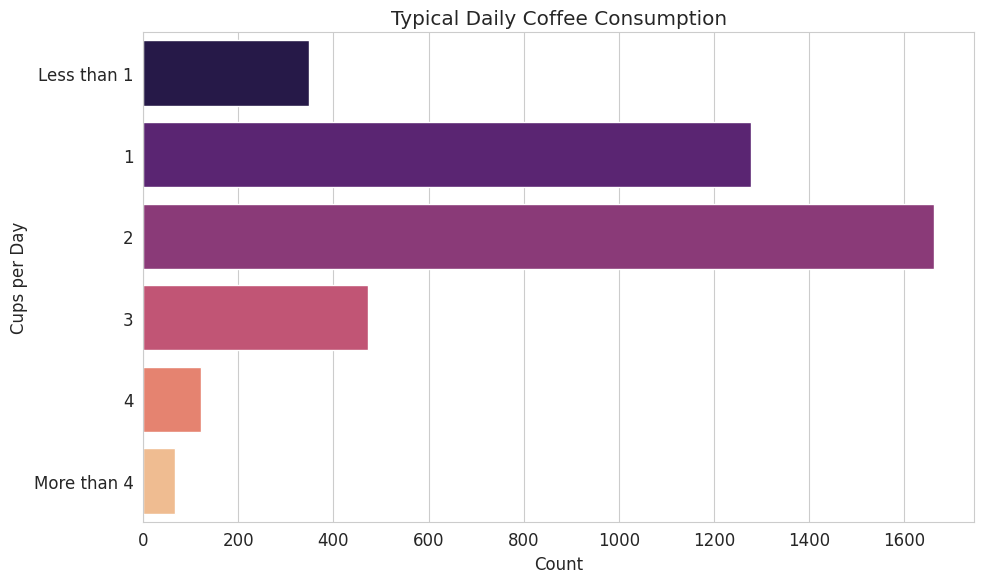

        Plot saved to 'plots/home_brew_methods.png'


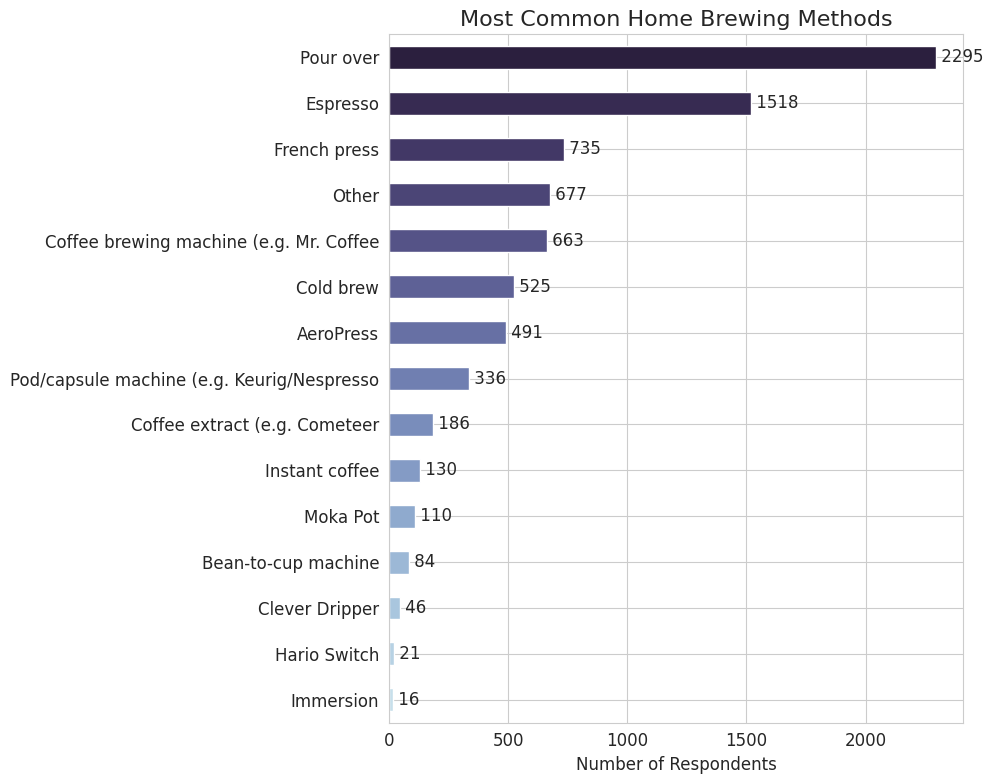

        Plot saved to 'plots/consumption_locations.png'


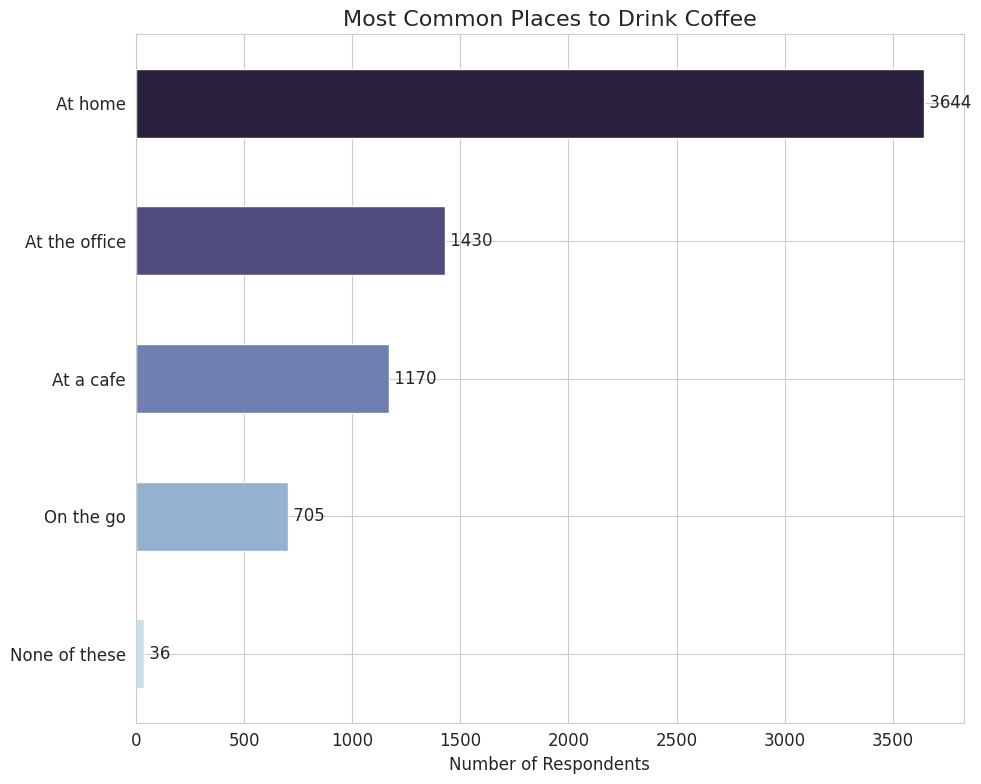


--- 2.3: Analyzing Preferences ---
        Plot saved to 'plots/favorite_drinks.png'


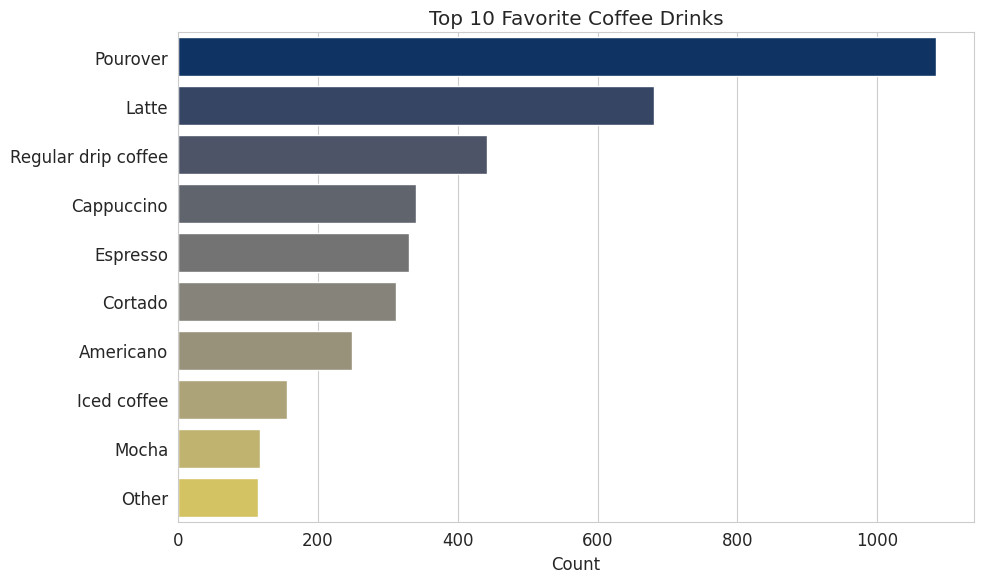

        Plot saved to 'plots/common_additions.png'


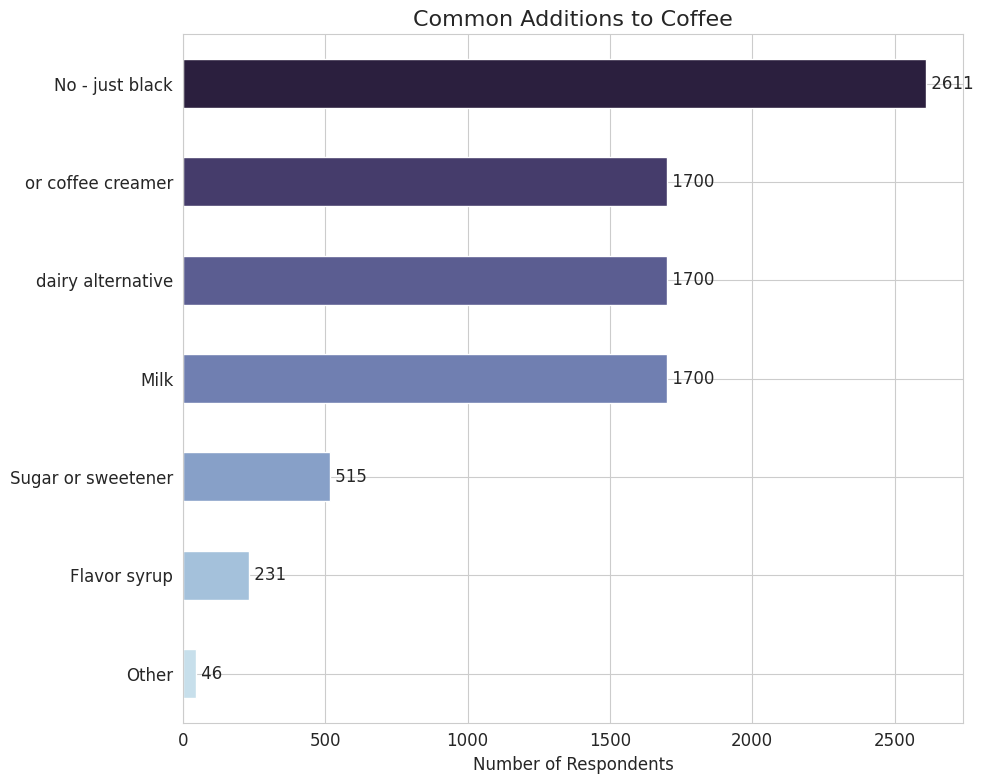

        Plot saved to 'plots/preferred_roast.png'


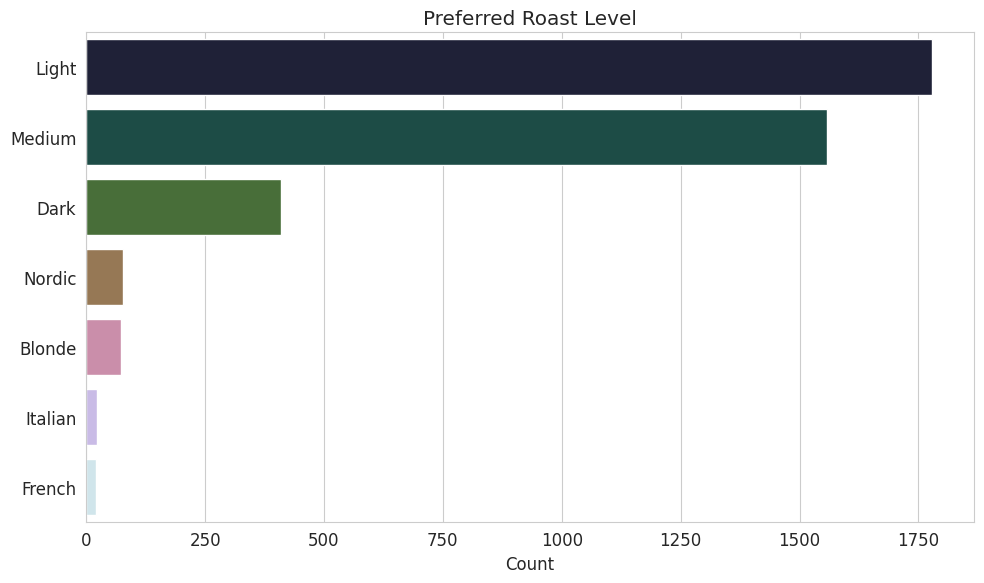


--- 2.4: Analyzing Spending and Expertise ---
        Plot saved to 'plots/monthly_spend.png'


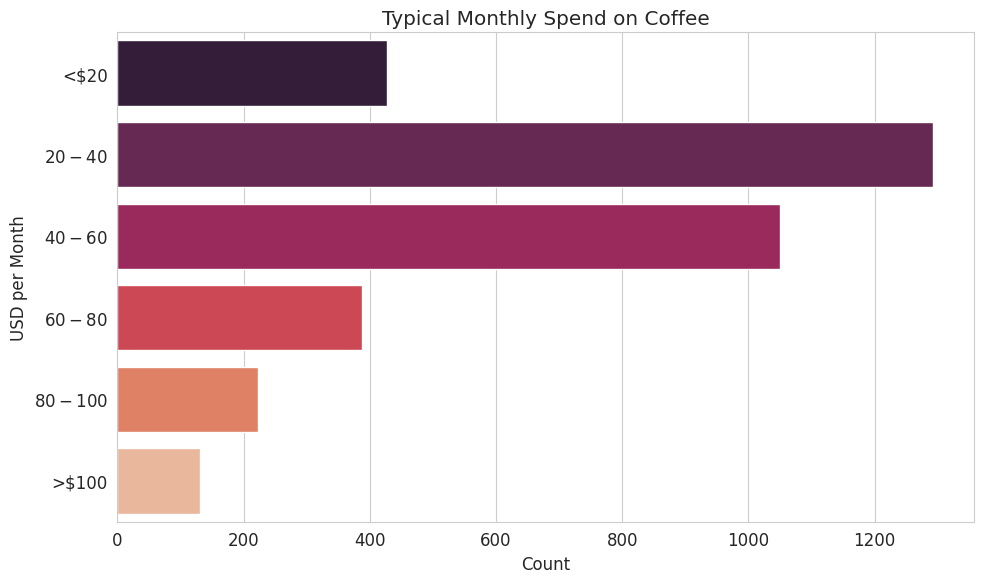

        Plot saved to 'plots/self_rated_expertise.png'


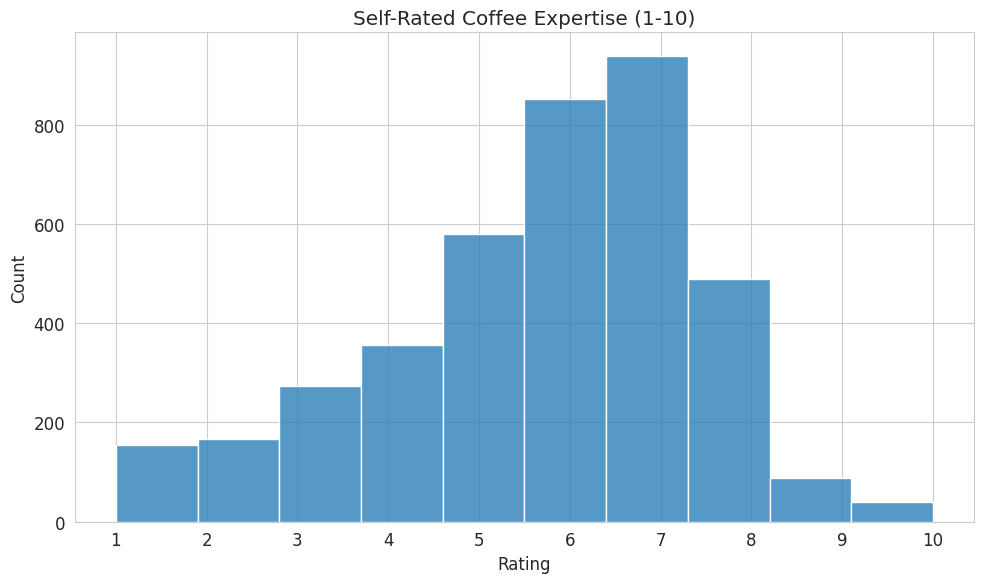


--- 2.5: Analyzing NLP Results from Tasting Notes ---
        Plot saved to 'plots/sentiment_distribution.png'


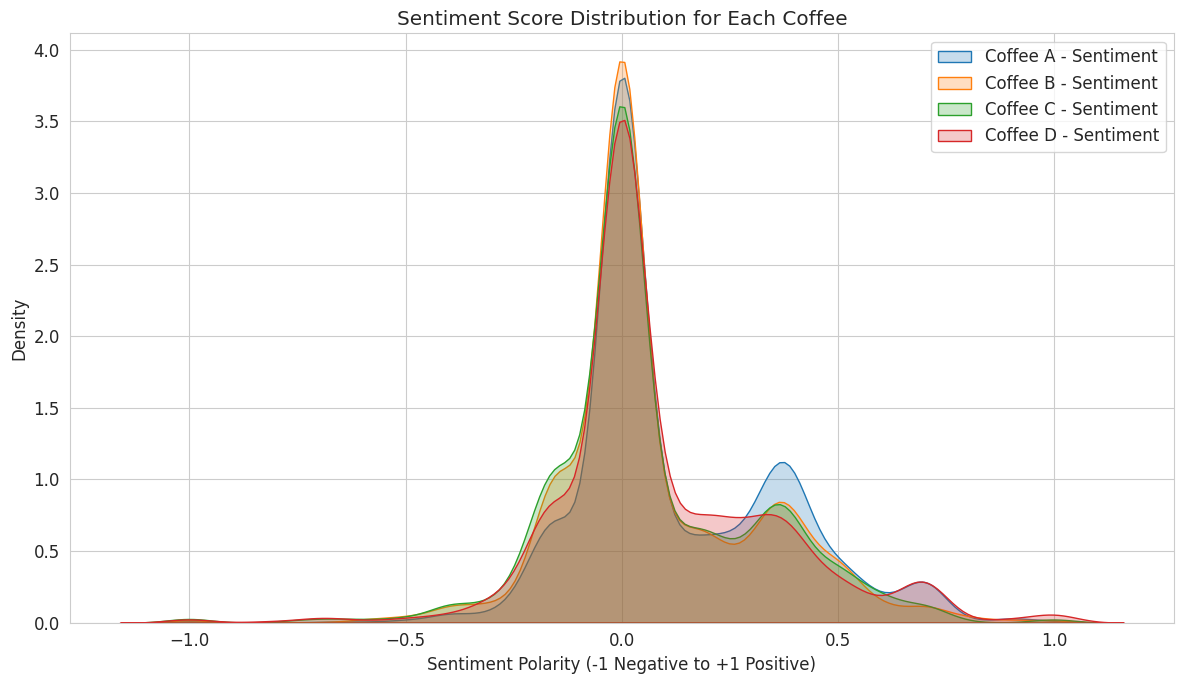

        Plot saved to 'plots/keywords_coffee_a.png'


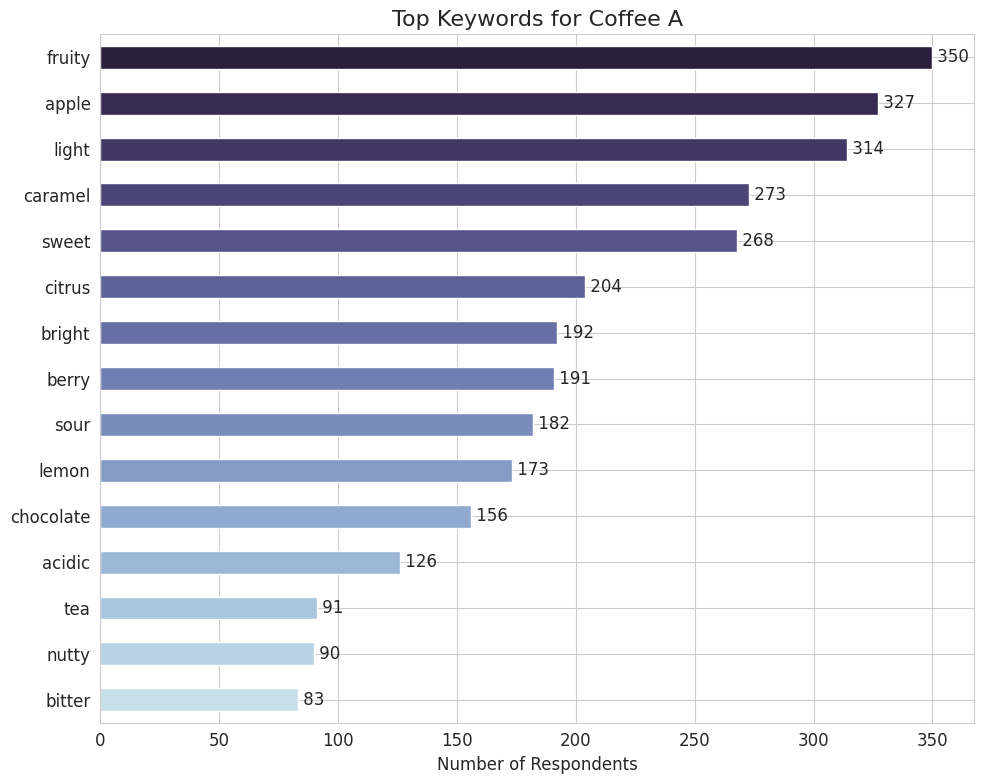

        Plot saved to 'plots/keywords_coffee_b.png'


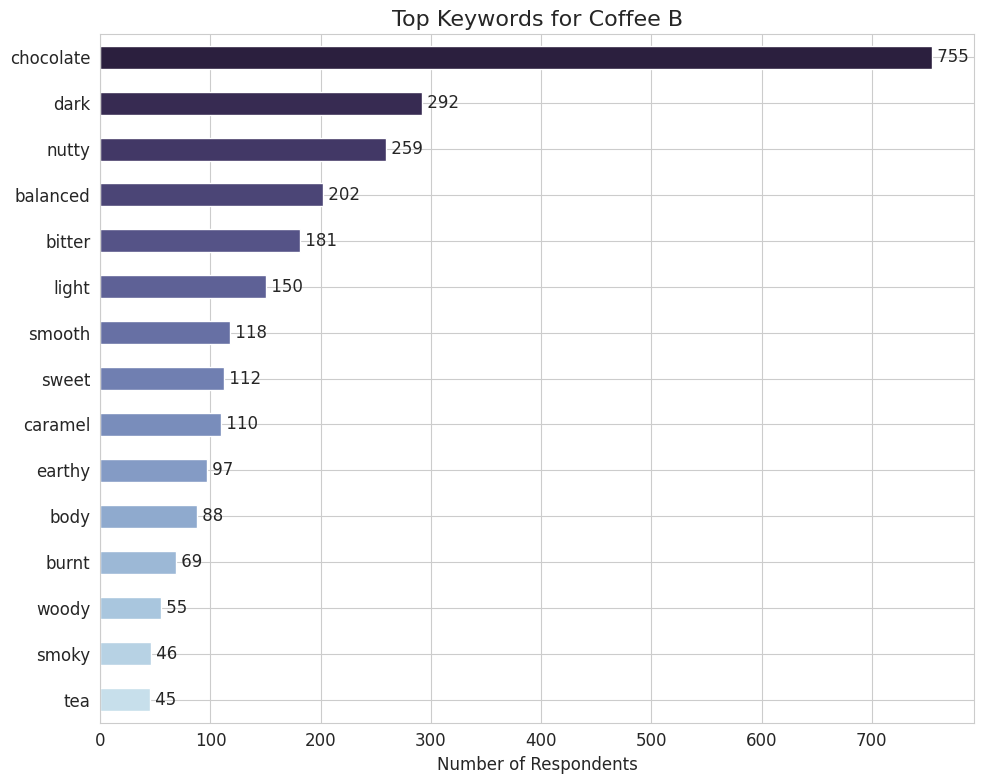

        Plot saved to 'plots/keywords_coffee_c.png'


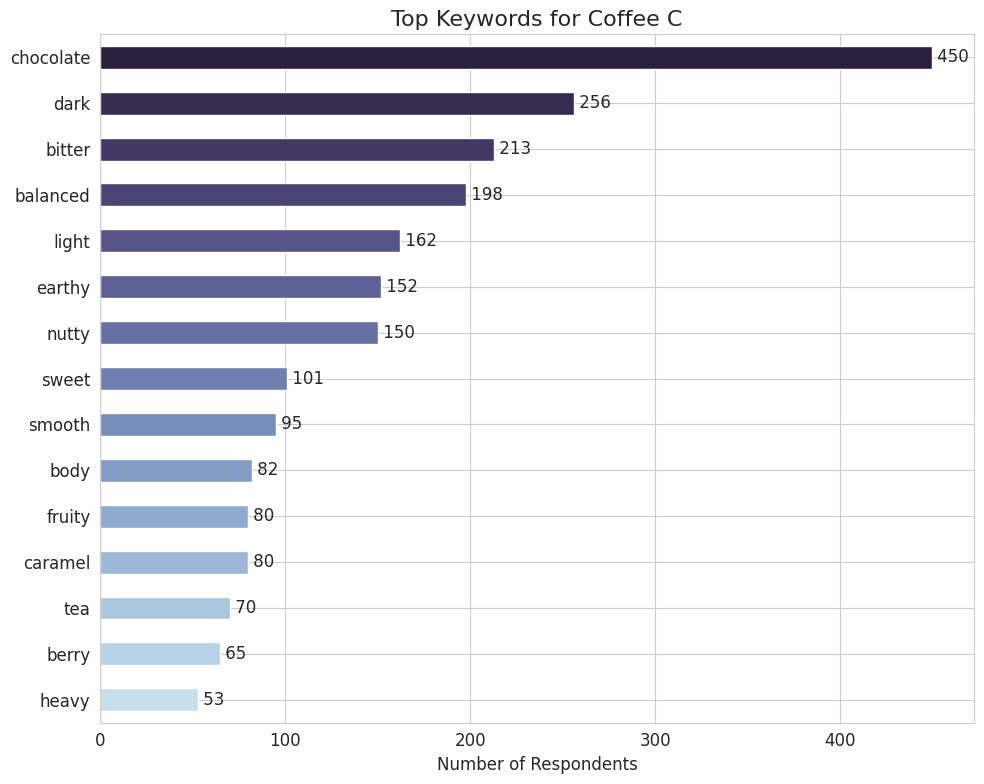

        Plot saved to 'plots/keywords_coffee_d.png'


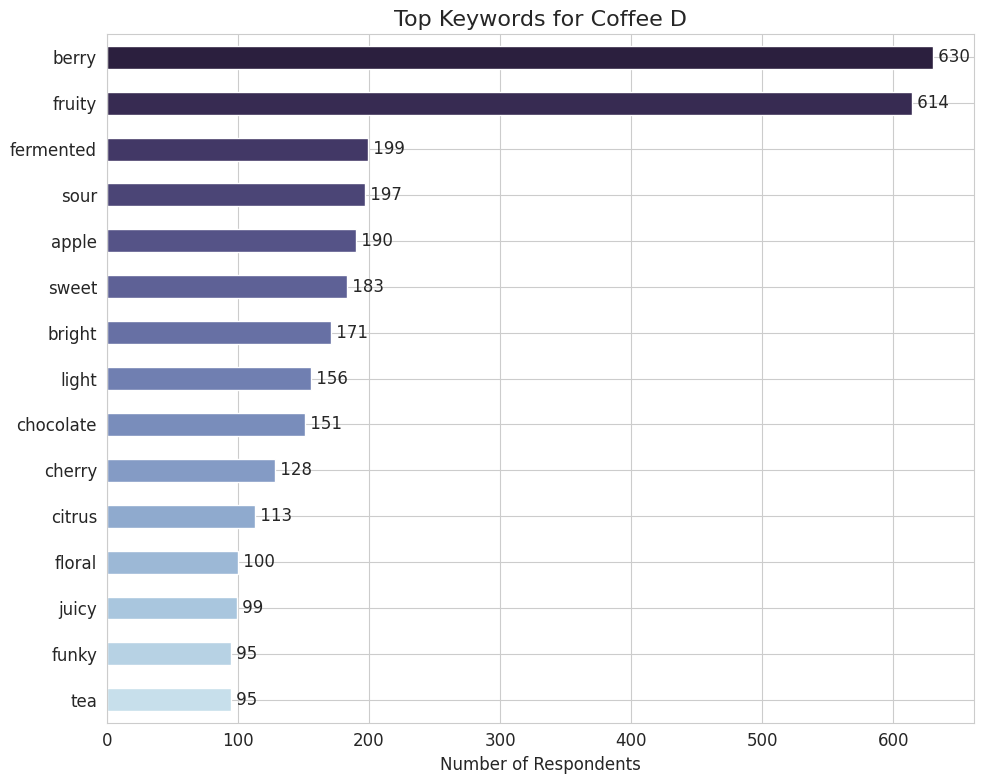


--- End of Step 2 ---


In [22]:
# --- Step 2: Exploratory Data Analysis (EDA) & Descriptive Statistics ---
#
# This script loads the final, cleaned dataset and performs a broad exploratory
# analysis to understand the distributions and characteristics of the respondents
# and their coffee habits. It uses matplotlib and seaborn for visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# --- Helper Function for Multi-Select Analysis ---
def plot_multi_select_col(df, column_name, title, filename, top_n=15):
    """
    Takes a dataframe and a column with comma-separated values,
    counts the occurrences of each value, and plots a horizontal bar chart.
    It also saves the plot to a file.
    """
    if column_name not in df.columns:
        print(f"Warning: Column '{column_name}' not found. Skipping plot.")
        return

    # Drop NA, split strings into lists, and explode into separate rows
    selections = df[column_name].dropna().str.split(', ').explode()

    # Get value counts and select top N
    counts = selections.value_counts().nlargest(top_n).sort_values(ascending=True)

    if counts.empty:
        print(f"No data to plot for '{column_name}'.")
        return

    # Plotting
    plt.figure(figsize=(10, 8))
    counts.plot(kind='barh', color=sns.color_palette("ch:s=.25,rot=-.25", n_colors=len(counts)))
    plt.title(title, fontsize=16)
    plt.xlabel('Number of Respondents', fontsize=12)
    plt.ylabel('')
    # Add data labels to the bars
    for index, value in enumerate(counts):
        plt.text(value, index, f' {value}', va='center')
    plt.tight_layout()

    # Save the plot before showing it
    plt.savefig(filename, bbox_inches='tight', dpi=150)
    print(f"        Plot saved to '{filename}'")

    plt.show()

# --- Main Execution ---
try:
    df = pd.read_csv('coffee_data_final_analysis_ready.csv')
    print("Successfully loaded 'coffee_data_final_analysis_ready.csv'.")
except FileNotFoundError:
    print("Error: 'coffee_data_final_analysis_ready.csv' not found. Please run the previous cleaning steps first.")
    df = pd.DataFrame()

if not df.empty:
    # Create a directory to store plots if it doesn't exist
    if not os.path.exists('plots'):
        os.makedirs('plots')
        print("Created 'plots' directory to save images.")

    # --- Set Plotting Style ---
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['font.size'] = 12

    print("\n--- 2.1: Analyzing Demographics ---")

    # Age Distribution
    age_order = ['<18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '>65 years old']
    plt.figure()
    sns.countplot(y=df['What is your age?'], order=age_order, palette='viridis')
    plt.title('Age Distribution of Respondents')
    plt.xlabel('Count')
    plt.ylabel('Age Group')
    plt.tight_layout()
    plt.savefig('plots/age_distribution.png', bbox_inches='tight', dpi=150)
    print("        Plot saved to 'plots/age_distribution.png'")
    plt.show()

    # Education Level
    edu_col = 'Education Level'
    plt.figure()
    sns.countplot(y=df[edu_col], order=df[edu_col].value_counts().index, palette='plasma')
    plt.title('Education Level of Respondents')
    plt.xlabel('Count')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig('plots/education_level.png', bbox_inches='tight', dpi=150)
    print("        Plot saved to 'plots/education_level.png'")
    plt.show()

    print("\n--- 2.2: Analyzing Consumption Habits ---")

    # Cups per day
    cups_col = 'How many cups of coffee do you typically drink per day?'
    cups_order = ['Less than 1', '1', '2', '3', '4', 'More than 4']
    plt.figure()
    sns.countplot(y=df[cups_col], order=cups_order, palette='magma')
    plt.title('Typical Daily Coffee Consumption')
    plt.xlabel('Count')
    plt.ylabel('Cups per Day')
    plt.tight_layout()
    plt.savefig('plots/daily_consumption.png', bbox_inches='tight', dpi=150)
    print("        Plot saved to 'plots/daily_consumption.png'")
    plt.show()

    # All Home Brew Methods
    plot_multi_select_col(df, 'All Home Brew Methods', 'Most Common Home Brewing Methods', filename='plots/home_brew_methods.png')

    # Where coffee is consumed
    plot_multi_select_col(df, 'Where do you typically drink coffee - Selections', 'Most Common Places to Drink Coffee', filename='plots/consumption_locations.png')

    print("\n--- 2.3: Analyzing Preferences ---")

    # Favorite Coffee Drink
    fav_drink_col = 'What is your favorite coffee drink?'
    plt.figure()
    sns.countplot(y=df[fav_drink_col], order=df[fav_drink_col].value_counts().nlargest(10).index, palette='cividis')
    plt.title('Top 10 Favorite Coffee Drinks')
    plt.xlabel('Count')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig('plots/favorite_drinks.png', bbox_inches='tight', dpi=150)
    print("        Plot saved to 'plots/favorite_drinks.png'")
    plt.show()

    # Additions to Coffee
    plot_multi_select_col(df, 'Do you usually add anything to your coffee - Selections', 'Common Additions to Coffee', filename='plots/common_additions.png')

    # Preferred Roast Level
    roast_col = 'What roast level of coffee do you prefer?'
    if roast_col in df.columns:
        plt.figure()
        sns.countplot(y=df[roast_col], order=df[roast_col].value_counts().index, palette='cubehelix')
        plt.title('Preferred Roast Level')
        plt.xlabel('Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.savefig('plots/preferred_roast.png', bbox_inches='tight', dpi=150)
        print("        Plot saved to 'plots/preferred_roast.png'")
        plt.show()

    print("\n--- 2.4: Analyzing Spending and Expertise ---")

    # Monthly Spend
    spend_col = 'In total, much money do you typically spend on coffee in a month?'
    spend_order = ['<$20', '$20-$40', '$40-$60', '$60-$80', '$80-$100', '>$100']
    if spend_col in df.columns:
        plt.figure()
        sns.countplot(y=df[spend_col], order=spend_order, palette='rocket')
        plt.title('Typical Monthly Spend on Coffee')
        plt.xlabel('Count')
        plt.ylabel('USD per Month')
        plt.tight_layout()
        plt.savefig('plots/monthly_spend.png', bbox_inches='tight', dpi=150)
        print("        Plot saved to 'plots/monthly_spend.png'")
        plt.show()

    # Self-Rated Expertise
    expertise_col = 'Lastly, how would you rate your own coffee expertise?'
    if expertise_col in df.columns:
        plt.figure()
        sns.histplot(df[expertise_col].dropna(), bins=10, kde=False)
        plt.title('Self-Rated Coffee Expertise (1-10)')
        plt.xlabel('Rating')
        plt.ylabel('Count')
        plt.xticks(range(1, 11))
        plt.tight_layout()
        plt.savefig('plots/self_rated_expertise.png', bbox_inches='tight', dpi=150)
        print("        Plot saved to 'plots/self_rated_expertise.png'")
        plt.show()

    print("\n--- 2.5: Analyzing NLP Results from Tasting Notes ---")

    # Sentiment Score Distributions
    sentiment_cols = [col for col in df.columns if 'Sentiment' in col]
    if sentiment_cols:
        plt.figure(figsize=(12, 7))
        for col in sentiment_cols:
            sns.kdeplot(df[col].dropna(), label=col, fill=True)
        plt.title('Sentiment Score Distribution for Each Coffee')
        plt.xlabel('Sentiment Polarity (-1 Negative to +1 Positive)')
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.savefig('plots/sentiment_distribution.png', bbox_inches='tight', dpi=150)
        print("        Plot saved to 'plots/sentiment_distribution.png'")
        plt.show()

    # Keyword Analysis
    plot_multi_select_col(df, 'Coffee A - Keywords', 'Top Keywords for Coffee A', filename='plots/keywords_coffee_a.png')
    plot_multi_select_col(df, 'Coffee B - Keywords', 'Top Keywords for Coffee B', filename='plots/keywords_coffee_b.png')
    plot_multi_select_col(df, 'Coffee C - Keywords', 'Top Keywords for Coffee C', filename='plots/keywords_coffee_c.png')
    plot_multi_select_col(df, 'Coffee D - Keywords', 'Top Keywords for Coffee D', filename='plots/keywords_coffee_d.png')

    print("\n--- End of Step 2 ---")
else:
    print("\nDataFrame is empty. Cannot perform analysis.")



## Step 3: Relationship Analysis & "Clever" Insights

Cross-Tabulations & Grouped Analysis: This is key to finding interesting patterns.

* Demographics vs. Habits/Preferences:

Does Age correlate with brew method, cups/day, favorite drink, or spending? (e.g., Age x Brew Method, Age x Monthly Spend).

Does Education or Employment relate to equipment spending or preferred brew methods?

* Expertise vs. Everything:

How does Self-Rated Expertise correlate with: Preferred Brew Method (expect Pour Over/Espresso higher?), Additions (expect more Black?), Roast/Strength preference, Equipment Spend, Tasting Preferences?

* Preferences vs. Habits:

Do people preferring Light Roasts use specific brew methods?

Do those preferring Fruity/Bright profiles align with certain brew methods or drink choices (e.g., Pourover)?

Do users of specific Brew Methods (e.g., Espresso) have distinct preferences for strength, favorite drinks (Cappuccino/Latte?), or additions?

* Spending vs. Habits/Preferences:

Does higher Equipment Spend strongly correlate with Espresso/Pour Over use and higher Expertise?

Does higher Monthly Spend correlate with frequent Cafe/On-the-Go consumption?

Work Location vs. Habits: Compare brewing locations, methods, and spending for WFH vs. In-Person vs. Hybrid workers.

* Statistical Tests (Optional but adds rigor):

Use Chi-Squared tests for independence between key categorical variables (e.g., is the relationship between Age Group and Primary Brew Method statistically significant within this sample?). Be mindful of cell count requirements for validity.

Visualizations: Use grouped or stacked bar charts, heatmaps for cross-tabulations, or box plots (if ranges can be reasonably converted/ordered) to illustrate relationships.


Successfully loaded 'coffee_data_final_analysis_ready.csv'.

Dataset has 4041 rows and 64 columns.

--- 3.1: Engineering Features for Analysis ---
        Created boolean flags for coffee additions (e.g., 'Adds_Milk_Alt').
        Created 'Expertise_Group' categories from 'Lastly, how would you rate your own coffee expertise?'.

--- 3.2: Analyzing by Self-Rated Expertise ---
        - Generated plot for Expertise vs. Drinking Black.


<Figure size 1000x600 with 0 Axes>

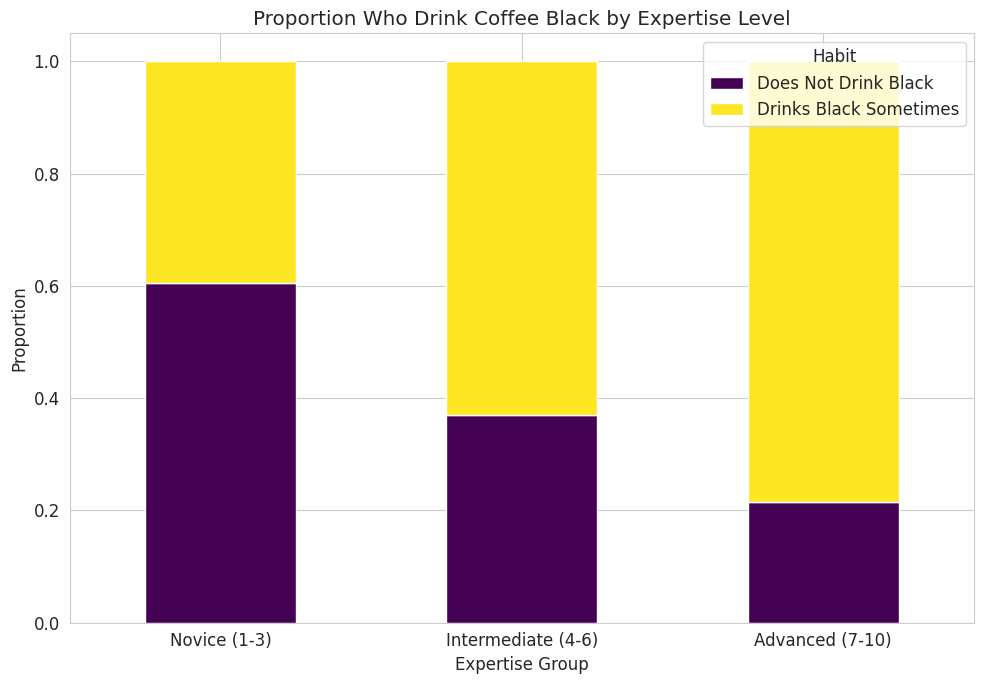

        - Generated plot for Expertise vs. Monthly Spend.


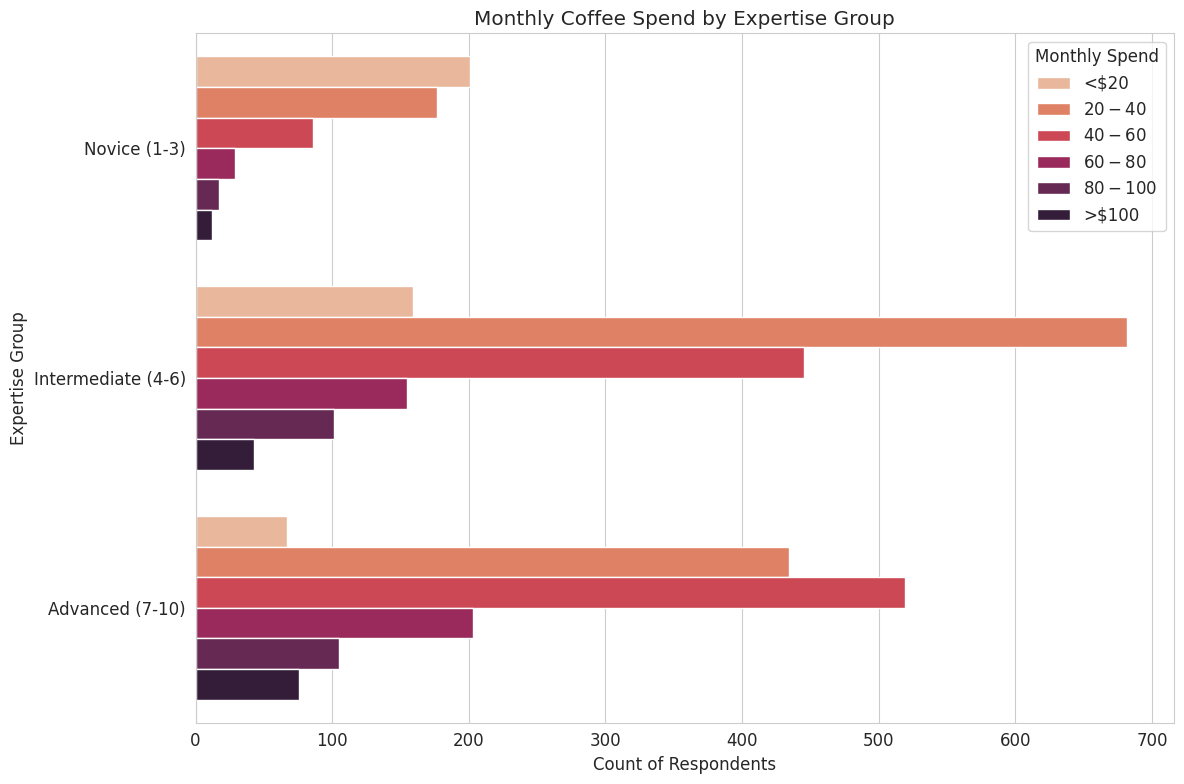


--- 3.3: Comparing Stated Preferences with Tasting Results ---
        - Generated plot for Stated Preference vs. Actual Favorite.


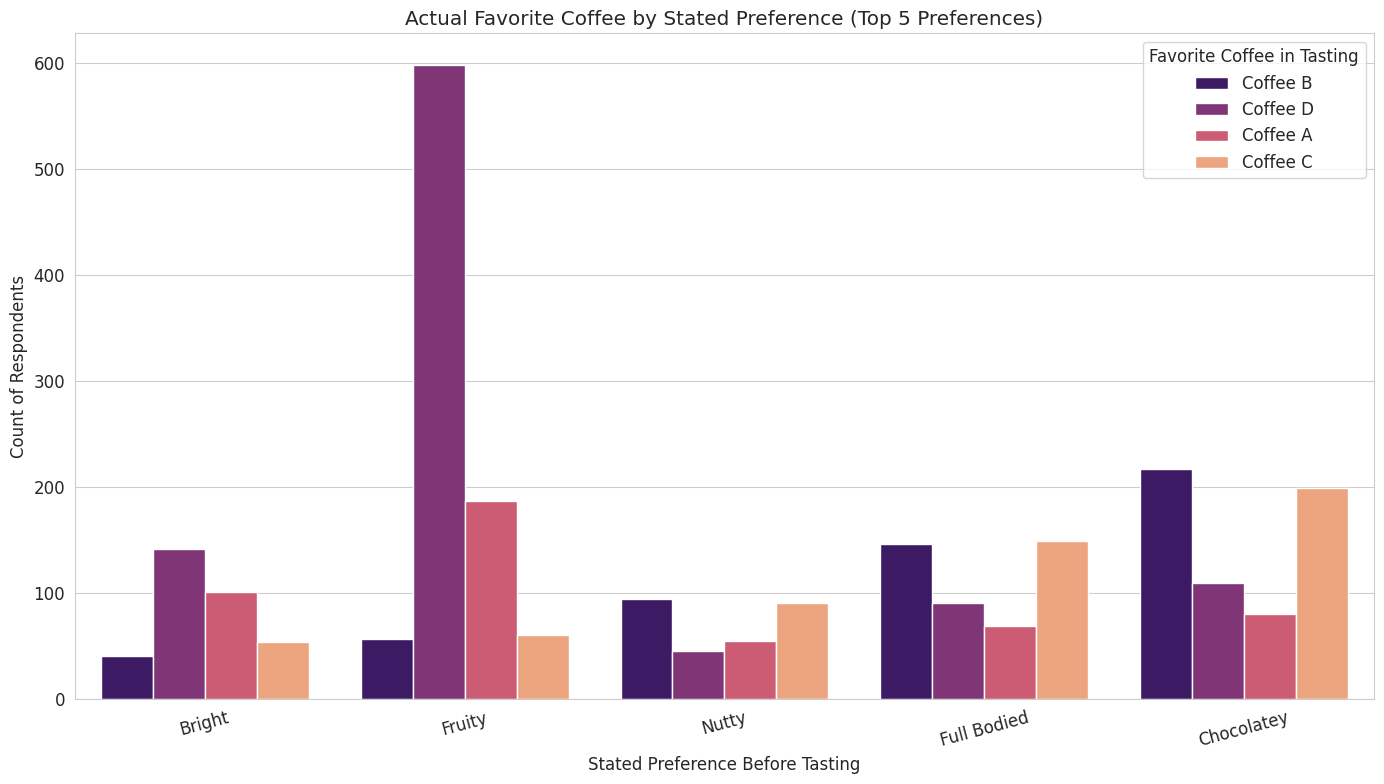


--- 3.4: Performing Chi-Squared Statistical Tests ---

    Test 1: Is there a significant association between Expertise and Favorite Coffee?
    H0: There is no association between a person's expertise group and their favorite coffee.
    - Chi-Squared Statistic: 174.76
    - P-value: 0.0000
    - Result: P-value is less than 0.05. We reject the null hypothesis.
      Conclusion: There is a statistically significant association between expertise and favorite coffee.

    Test 2: Is there a significant association between Stated Preference and Favorite Coffee?
    H0: There is no association between a person's stated preference and their favorite coffee.
    - Chi-Squared Statistic: 748.58
    - P-value: 0.0000
    - Result: P-value is less than 0.05. We reject the null hypothesis.
      Conclusion: There is a statistically significant association between stated preference and the actual favorite coffee.

--- End of Step 3 ---


In [23]:
# --- Step 3: Relationship Analysis & "Clever" Insights ---
#
# This script loads the final cleaned and standardized dataset and performs
# grouped analysis, cross-tabulations, and basic statistical tests to uncover
# relationships between different variables.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import os

# --- Main Execution ---
try:
    df = pd.read_csv('coffee_data_final_analysis_ready.csv')
    print("Successfully loaded 'coffee_data_final_analysis_ready.csv'.")
except FileNotFoundError:
    print("Error: 'coffee_data_final_analysis_ready.csv' not found. Please run the previous cleaning steps first.")
    df = pd.DataFrame()

if not df.empty:
    # --- Setup ---
    # Ensure plots directory exists
    if not os.path.exists('plots'):
        os.makedirs('plots')

    sns.set_style("whitegrid")
    print(f"\nDataset has {df.shape[0]} rows and {df.shape[1]} columns.")

    # --- 3.1: Feature Engineering for Easier Analysis ---
    print("\n--- 3.1: Engineering Features for Analysis ---")

    # Create boolean flags from multi-select "Additions" column
    additions_col = 'Do you usually add anything to your coffee - Selections'
    if additions_col in df.columns:
        df['Adds_Milk_Alt'] = df[additions_col].str.contains('Milk', na=False)
        df['Adds_Sweetener'] = df[additions_col].str.contains('Sugar', na=False)
        df['Drinks_Black_Sometimes'] = df[additions_col].str.contains('No - just black', na=False)
        print("        Created boolean flags for coffee additions (e.g., 'Adds_Milk_Alt').")

    # Create categorical bins for expertise
    expertise_col = 'Lastly, how would you rate your own coffee expertise?'
    if expertise_col in df.columns:
        bins = [0, 3, 6, 10]
        labels = ['Novice (1-3)', 'Intermediate (4-6)', 'Advanced (7-10)']
        df['Expertise_Group'] = pd.cut(df[expertise_col], bins=bins, labels=labels, right=True)
        print(f"        Created 'Expertise_Group' categories from '{expertise_col}'.")

    # --- 3.2: Expertise vs. Habits & Spending ---
    print("\n--- 3.2: Analyzing by Self-Rated Expertise ---")

    # Expertise vs. Additions
    if 'Expertise_Group' in df.columns and 'Drinks_Black_Sometimes' in df.columns:
        expertise_additions = df.groupby('Expertise_Group')['Drinks_Black_Sometimes'].value_counts(normalize=True).unstack()
        expertise_additions.columns = ['Does Not Drink Black', 'Drinks Black Sometimes']

        plt.figure()
        expertise_additions.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='viridis')
        plt.title('Proportion Who Drink Coffee Black by Expertise Level')
        plt.xlabel('Expertise Group')
        plt.ylabel('Proportion')
        plt.xticks(rotation=0)
        plt.legend(title='Habit')
        plt.tight_layout()
        plt.savefig('plots/expertise_vs_drinks_black.png', dpi=150)
        print("        - Generated plot for Expertise vs. Drinking Black.")
        plt.show()

    # Expertise vs. Spending
    spend_col = 'In total, much money do you typically spend on coffee in a month?'
    if 'Expertise_Group' in df.columns and spend_col in df.columns:
        plt.figure(figsize=(12, 8))
        sns.countplot(data=df, y='Expertise_Group', hue=spend_col, order=labels, hue_order=['<$20', '$20-$40', '$40-$60', '$60-$80', '$80-$100', '>$100'], palette='rocket_r')
        plt.title('Monthly Coffee Spend by Expertise Group')
        plt.xlabel('Count of Respondents')
        plt.ylabel('Expertise Group')
        plt.legend(title='Monthly Spend')
        plt.tight_layout()
        plt.savefig('plots/expertise_vs_monthly_spend.png', dpi=150)
        print("        - Generated plot for Expertise vs. Monthly Spend.")
        plt.show()

    # --- 3.3: Tasting Preferences vs. Stated Preferences ---
    print("\n--- 3.3: Comparing Stated Preferences with Tasting Results ---")

    fav_overall_col = 'Lastly, what was your favorite overall coffee?'
    stated_pref_col = 'Before today\'s tasting, which of the following best described what kind of coffee you like?'

    if fav_overall_col in df.columns and stated_pref_col in df.columns:
        # Filter for rows where both columns have data
        comparison_df = df.dropna(subset=[fav_overall_col, stated_pref_col])

        # Limit to the most common stated preferences for clarity
        top_stated_prefs = comparison_df[stated_pref_col].value_counts().nlargest(5).index
        comparison_df_filtered = comparison_df[comparison_df[stated_pref_col].isin(top_stated_prefs)]

        plt.figure(figsize=(14, 8))
        sns.countplot(data=comparison_df_filtered, x=stated_pref_col, hue=fav_overall_col, palette='magma')
        plt.title('Actual Favorite Coffee by Stated Preference (Top 5 Preferences)')
        plt.xlabel('Stated Preference Before Tasting')
        plt.ylabel('Count of Respondents')
        plt.xticks(rotation=15)
        plt.legend(title='Favorite Coffee in Tasting')
        plt.tight_layout()
        plt.savefig('plots/stated_vs_actual_preference.png', dpi=150)
        print("        - Generated plot for Stated Preference vs. Actual Favorite.")
        plt.show()

    # --- 3.4: Statistical Tests ---
    print("\n--- 3.4: Performing Chi-Squared Statistical Tests ---")

    # Test 1: Expertise Group vs. Favorite Overall Coffee
    if 'Expertise_Group' in df.columns and fav_overall_col in df.columns:
        print("\n    Test 1: Is there a significant association between Expertise and Favorite Coffee?")
        print("    H0: There is no association between a person's expertise group and their favorite coffee.")

        contingency_table = pd.crosstab(df['Expertise_Group'], df[fav_overall_col])
        chi2, p, dof, ex = chi2_contingency(contingency_table)

        print(f"    - Chi-Squared Statistic: {chi2:.2f}")
        print(f"    - P-value: {p:.4f}")

        alpha = 0.05
        if p < alpha:
            print(f"    - Result: P-value is less than {alpha}. We reject the null hypothesis.")
            print("      Conclusion: There is a statistically significant association between expertise and favorite coffee.")
        else:
            print(f"    - Result: P-value is greater than {alpha}. We fail to reject the null hypothesis.")
            print("      Conclusion: There is not enough evidence of an association between expertise and favorite coffee.")

    # Test 2: Stated Preference vs. Favorite Overall Coffee
    if fav_overall_col in df.columns and stated_pref_col in df.columns:
        print("\n    Test 2: Is there a significant association between Stated Preference and Favorite Coffee?")
        print("    H0: There is no association between a person's stated preference and their favorite coffee.")

        # Using the filtered data for a cleaner test on the most common groups
        contingency_table_2 = pd.crosstab(comparison_df_filtered[stated_pref_col], comparison_df_filtered[fav_overall_col])
        chi2, p, dof, ex = chi2_contingency(contingency_table_2)

        print(f"    - Chi-Squared Statistic: {chi2:.2f}")
        print(f"    - P-value: {p:.4f}")

        if p < alpha:
            print(f"    - Result: P-value is less than {alpha}. We reject the null hypothesis.")
            print("      Conclusion: There is a statistically significant association between stated preference and the actual favorite coffee.")
        else:
            print(f"    - Result: P-value is greater than {alpha}. We fail to reject the null hypothesis.")
            print("      Conclusion: There is not enough evidence of an association between stated preference and the actual favorite coffee.")

    print("\n--- End of Step 3 ---")
else:
    print("\nDataFrame is empty. Cannot perform analysis.")


Successfully loaded 'coffee_data_final_analysis_ready.csv'.

Dataset has 4041 rows and 64 columns.

--- 1. Analyzing Demographics vs. Habits/Preferences ---
        - Generated heatmap for Age vs. Brew Method.


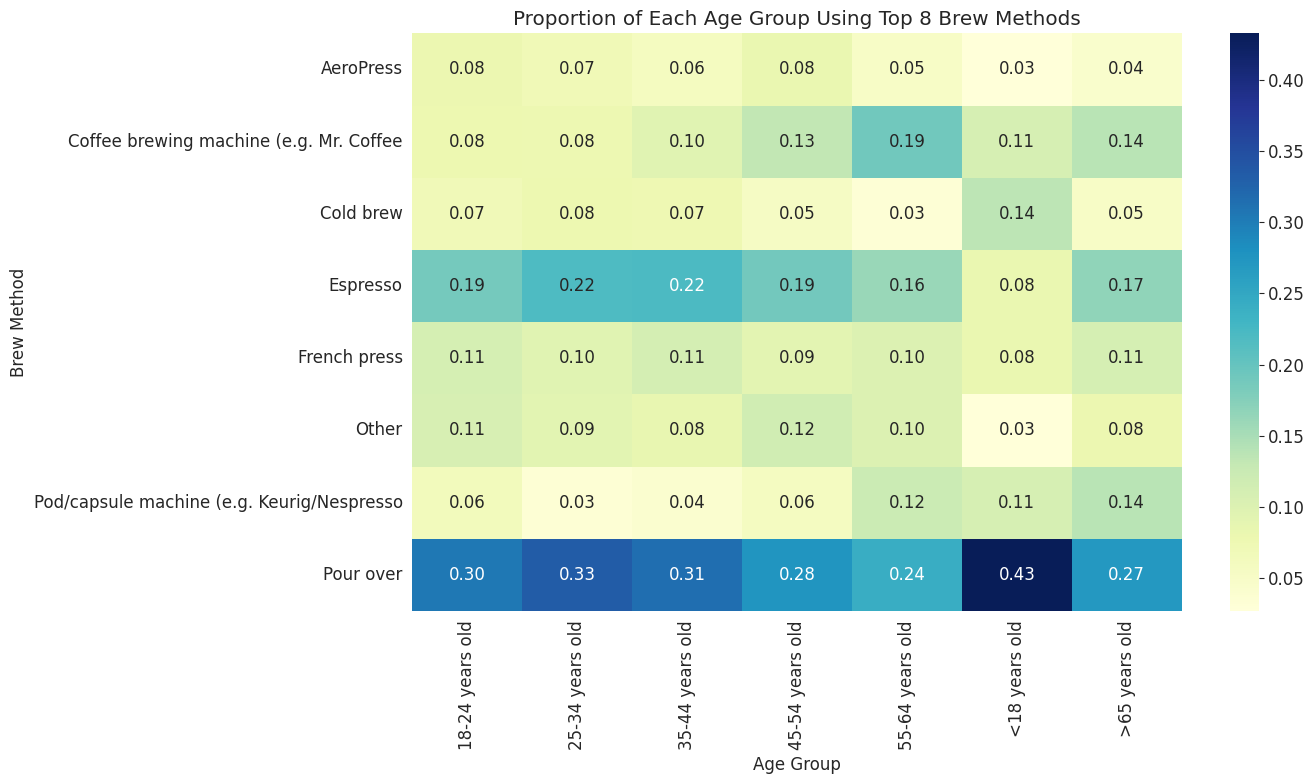

        - Generated plot for Education vs. Equipment Spend.


<Figure size 1000x600 with 0 Axes>

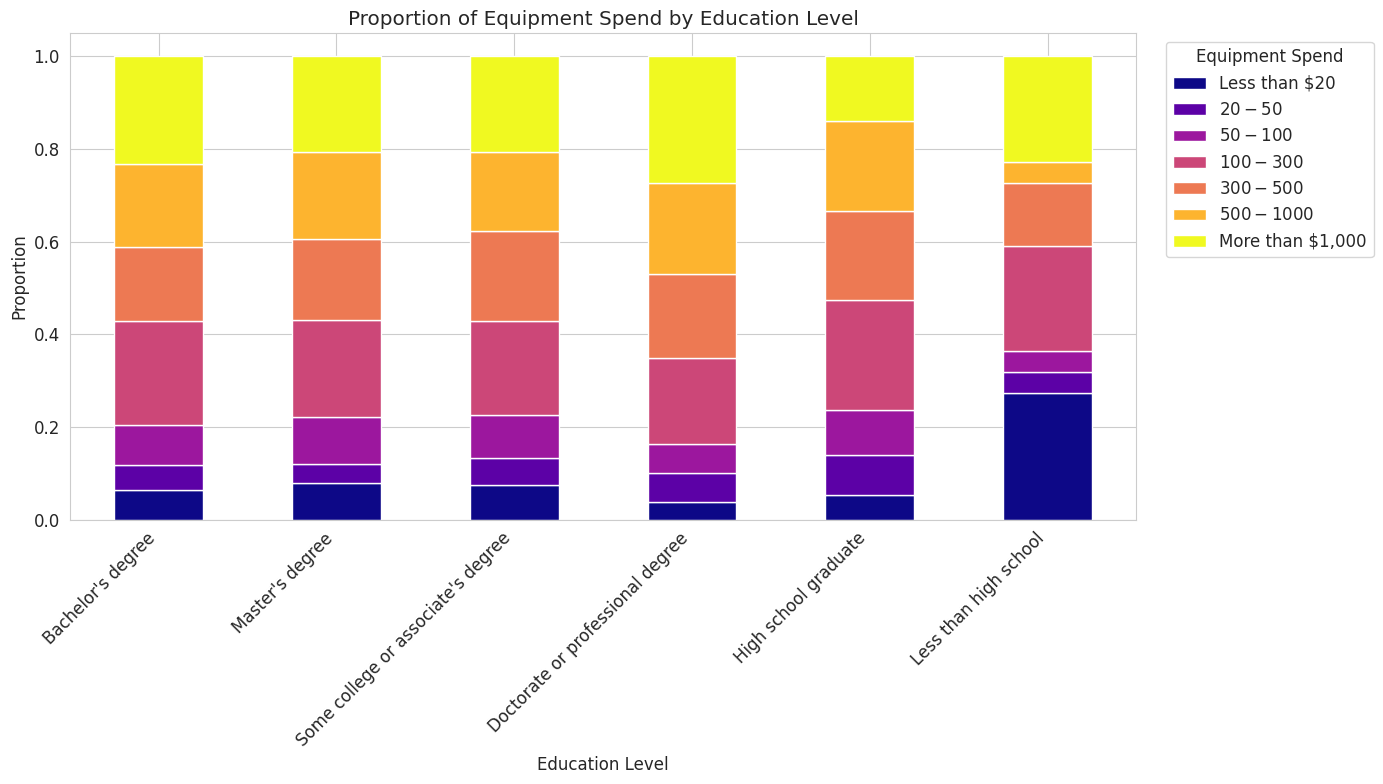


--- 2. Analyzing Expertise vs. Habits/Preferences ---
        - Generated heatmap for Expertise vs. Brew Method.


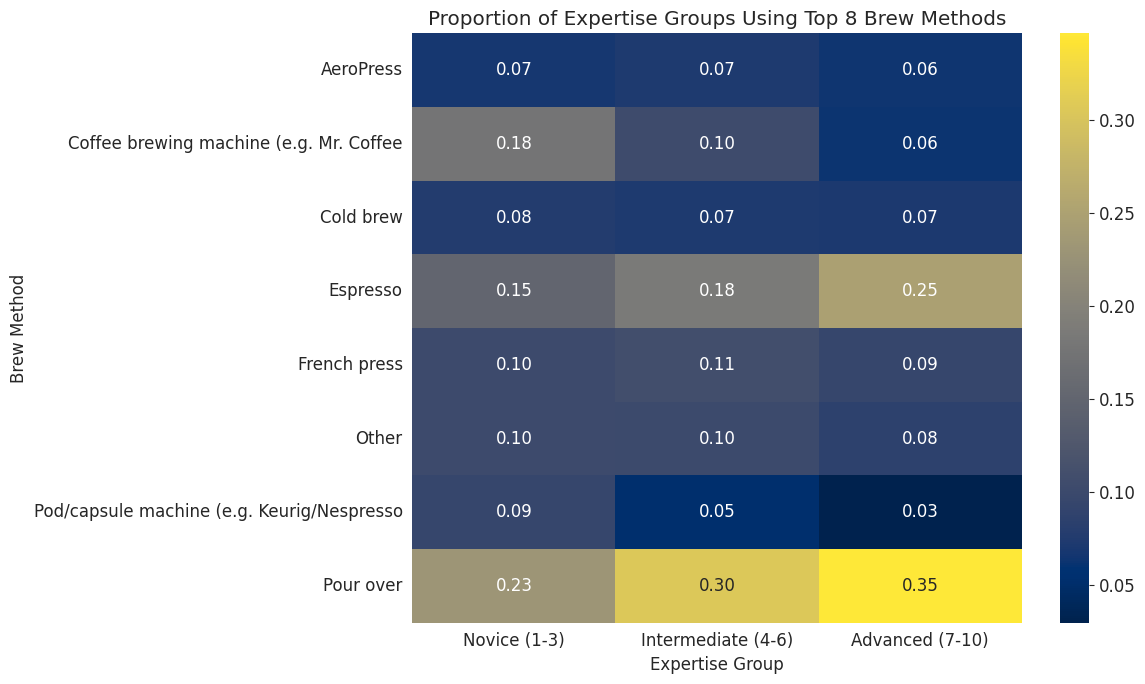


--- 3. Analyzing Stated Preferences vs. Habits ---
        - Generated heatmap for Stated Preference vs. Brew Method.


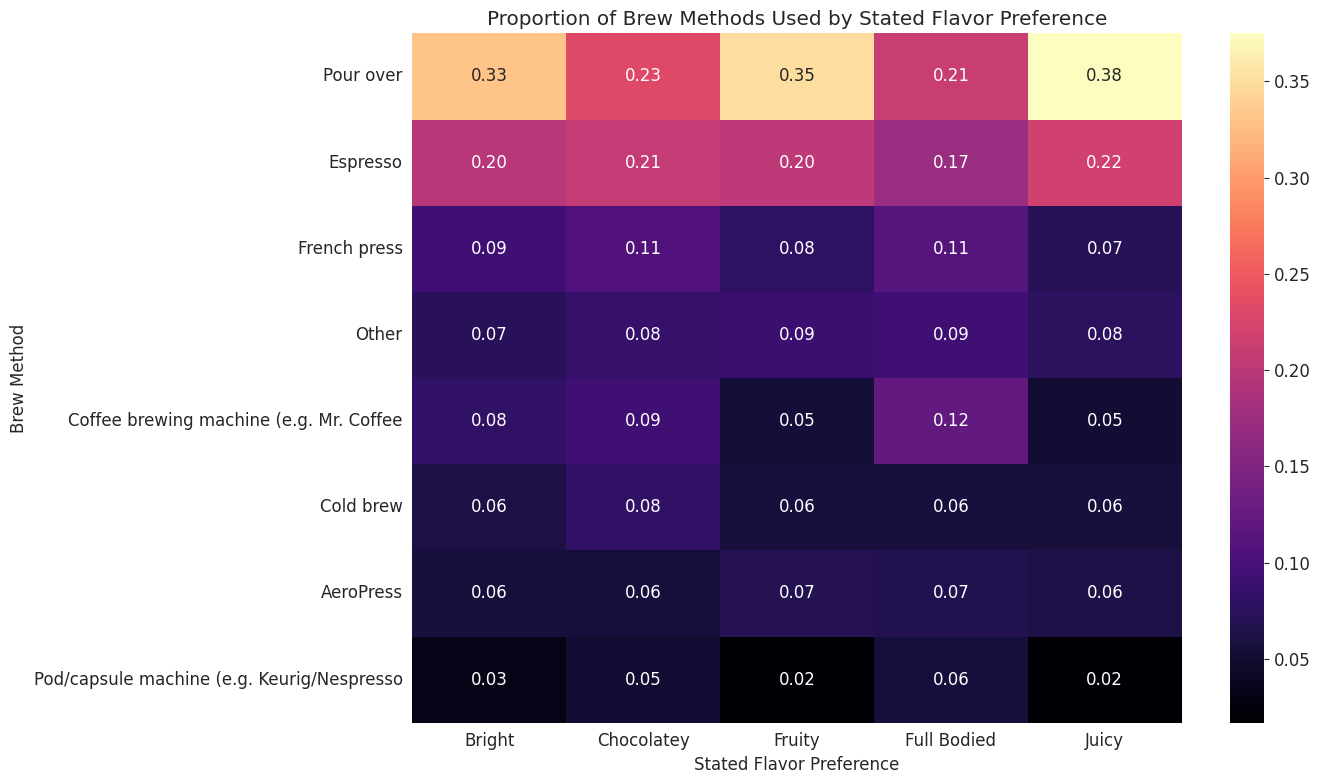


--- 4. Analyzing Work Location vs. Habits ---
        - Generated plot for Work Style vs. Consumption Location.


<Figure size 1000x600 with 0 Axes>

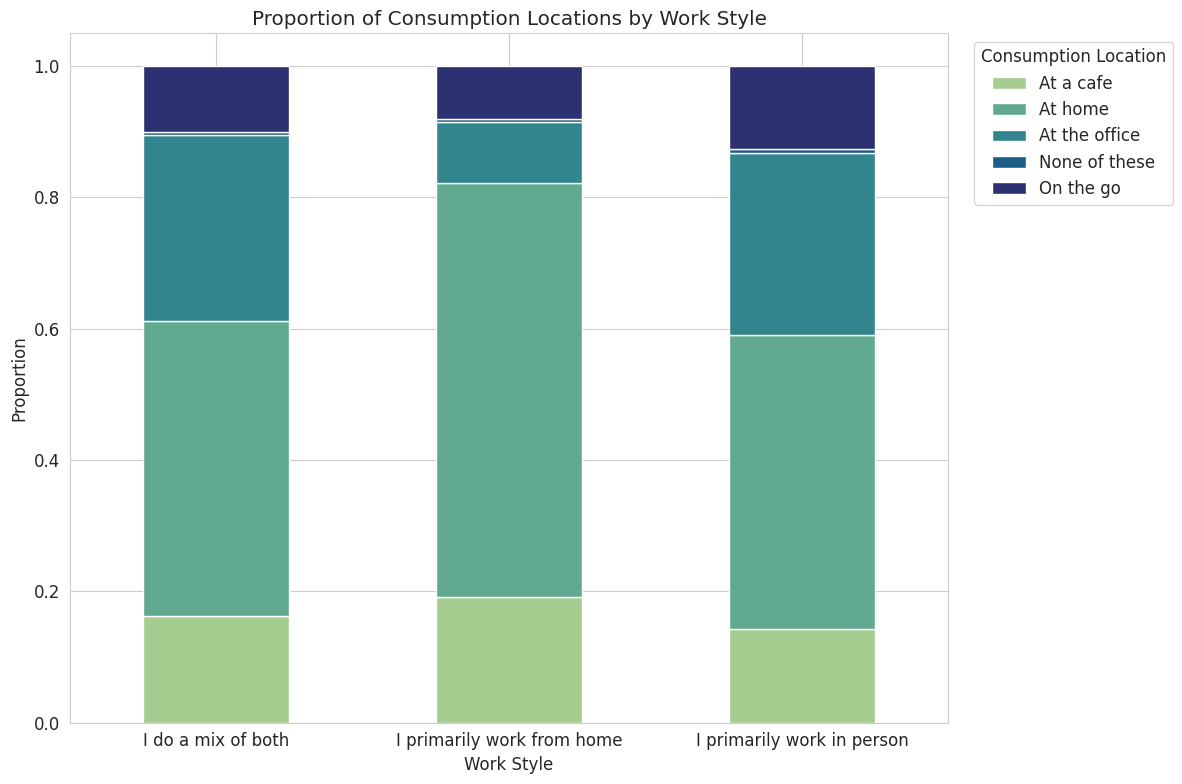


--- 5. Performing Additional Chi-Squared Tests ---

    Chi-Squared Test: 'Age Group' vs 'Monthly Spend'
    - H0: There is no association between 'Age Group' and 'Monthly Spend'.
    - Chi-Squared Statistic: 108.27, P-value: 0.0000
    - Result: P-value is less than 0.05. We reject the null hypothesis.
      Conclusion: There is a statistically significant association.

    Chi-Squared Test: 'Expertise_Group' vs 'Equipment Spend'
    - H0: There is no association between 'Expertise_Group' and 'Equipment Spend'.
    - Chi-Squared Statistic: 1001.57, P-value: 0.0000
    - Result: P-value is less than 0.05. We reject the null hypothesis.
      Conclusion: There is a statistically significant association.

    Chi-Squared Test: 'Work Style' vs 'Monthly Spend'
    - H0: There is no association between 'Work Style' and 'Monthly Spend'.
    - Chi-Squared Statistic: 40.06, P-value: 0.0000
    - Result: P-value is less than 0.05. We reject the null hypothesis.
      Conclusion: There is a sta

In [25]:
# --- Step 3b: Deep Dive Relationship Analysis ---
#
# This script performs a detailed investigation into the relationships between
# different variables in the cleaned coffee dataset, addressing specific
# questions about how demographics, expertise, and preferences correlate with habits.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import os

# --- Helper Function for Statistical Tests ---
def perform_chi_squared_test(df, col1, col2, alpha=0.05):
    """Performs a Chi-Squared test and prints the conclusion."""
    if col1 not in df.columns or col2 not in df.columns:
        print(f"    - Skipping test: One or both columns ('{col1}', '{col2}') not found.")
        return

    # Create a contingency table, dropping rows where either column is NaN
    contingency_table = pd.crosstab(df[col1], df[col2])

    # The test is not reliable if cells have low expected frequencies
    chi2, p, dof, ex = chi2_contingency(contingency_table)

    print(f"\n    Chi-Squared Test: '{col1}' vs '{col2}'")
    print(f"    - H0: There is no association between '{col1}' and '{col2}'.")
    print(f"    - Chi-Squared Statistic: {chi2:.2f}, P-value: {p:.4f}")

    if p < alpha:
        print(f"    - Result: P-value is less than {alpha}. We reject the null hypothesis.")
        print("      Conclusion: There is a statistically significant association.")
    else:
        print(f"    - Result: P-value is greater than {alpha}. We fail to reject the null hypothesis.")
        print("      Conclusion: There is no statistically significant association.")

# --- Main Execution ---
try:
    df = pd.read_csv('coffee_data_final_analysis_ready.csv')
    print("Successfully loaded 'coffee_data_final_analysis_ready.csv'.")
except FileNotFoundError:
    print("Error: 'coffee_data_final_analysis_ready.csv' not found. Please run the previous cleaning steps first.")
    df = pd.DataFrame()

if not df.empty:
    # --- Setup ---
    if not os.path.exists('plots'):
        os.makedirs('plots')

    sns.set_style("whitegrid")
    print(f"\nDataset has {df.shape[0]} rows and {df.shape[1]} columns.")

    # --- Feature Engineering (from previous step, for completeness) ---
    expertise_col = 'Lastly, how would you rate your own coffee expertise?'
    if expertise_col in df.columns:
        bins = [0, 3, 6, 10]
        labels = ['Novice (1-3)', 'Intermediate (4-6)', 'Advanced (7-10)']
        df['Expertise_Group'] = pd.cut(df[expertise_col], bins=bins, labels=labels, right=True)

    # --- 1. Demographics vs. Habits/Preferences ---
    print("\n--- 1. Analyzing Demographics vs. Habits/Preferences ---")

    # Age vs. Brew Method
    age_col = 'What is your age?'
    brew_col = 'All Home Brew Methods'
    if age_col in df.columns and brew_col in df.columns:
        # Explode the multi-select brew methods
        age_brew_df = df[[age_col, brew_col]].dropna()
        age_brew_df = age_brew_df.assign(Method=age_brew_df[brew_col].str.split(', ')).explode('Method')

        # Get top methods to keep the plot clean
        top_methods = age_brew_df['Method'].value_counts().nlargest(8).index

        # **FIXED**: Perform normalization manually to avoid ValueError
        df_filtered_age = age_brew_df[age_brew_df['Method'].isin(top_methods)]
        age_brew_crosstab_counts = pd.crosstab(df_filtered_age[age_col], df_filtered_age['Method'])
        age_brew_crosstab = age_brew_crosstab_counts.div(age_brew_crosstab_counts.sum(axis=1), axis=0)

        plt.figure(figsize=(14, 8))
        sns.heatmap(age_brew_crosstab.T, annot=True, fmt='.2f', cmap='YlGnBu')
        plt.title('Proportion of Each Age Group Using Top 8 Brew Methods')
        plt.xlabel('Age Group')
        plt.ylabel('Brew Method')
        plt.tight_layout()
        plt.savefig('plots/age_vs_brew_method.png', dpi=150)
        print("        - Generated heatmap for Age vs. Brew Method.")
        plt.show()

    # Education vs. Equipment Spend
    edu_col = 'Education Level'
    equip_spend_col = 'Approximately how much have you spent on coffee equipment in the past 5 years?'
    if edu_col in df.columns and equip_spend_col in df.columns:
        spend_order = ['Less than $20', '$20-$50', '$50-$100', '$100-$300', '$300-$500', '$500-$1000', 'More than $1,000']
        edu_order = df[edu_col].value_counts().index

        # **FIXED**: Perform normalization manually
        edu_spend_crosstab_counts = pd.crosstab(df[edu_col], df[equip_spend_col])
        edu_spend_crosstab = edu_spend_crosstab_counts.div(edu_spend_crosstab_counts.sum(axis=1), axis=0)
        edu_spend_crosstab = edu_spend_crosstab.reindex(columns=spend_order, index=edu_order)

        plt.figure()
        edu_spend_crosstab.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='plasma')
        plt.title('Proportion of Equipment Spend by Education Level')
        plt.xlabel('Education Level')
        plt.ylabel('Proportion')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Equipment Spend', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig('plots/education_vs_equipment_spend.png', dpi=150)
        print("        - Generated plot for Education vs. Equipment Spend.")
        plt.show()

    # --- 2. Expertise vs. Everything ---
    print("\n--- 2. Analyzing Expertise vs. Habits/Preferences ---")

    # Expertise vs. Preferred Brew Method
    if 'Expertise_Group' in df.columns and brew_col in df.columns:
        exp_brew_df = df[['Expertise_Group', brew_col]].dropna()
        exp_brew_df = exp_brew_df.assign(Method=exp_brew_df[brew_col].str.split(', ')).explode('Method')

        # **FIXED**: Perform normalization manually
        df_filtered_exp = exp_brew_df[exp_brew_df['Method'].isin(top_methods)]
        exp_brew_crosstab_counts = pd.crosstab(df_filtered_exp['Expertise_Group'], df_filtered_exp['Method'])
        exp_brew_crosstab = exp_brew_crosstab_counts.div(exp_brew_crosstab_counts.sum(axis=1), axis=0)

        plt.figure(figsize=(12, 7))
        sns.heatmap(exp_brew_crosstab.T, annot=True, fmt='.2f', cmap='cividis')
        plt.title('Proportion of Expertise Groups Using Top 8 Brew Methods')
        plt.xlabel('Expertise Group')
        plt.ylabel('Brew Method')
        plt.tight_layout()
        plt.savefig('plots/expertise_vs_brew_method.png', dpi=150)
        print("        - Generated heatmap for Expertise vs. Brew Method.")
        plt.show()

    # --- 3. Preferences vs. Habits ---
    print("\n--- 3. Analyzing Stated Preferences vs. Habits ---")

    # Stated Flavor Profile vs. Brew Method
    stated_pref_col = 'Before today\'s tasting, which of the following best described what kind of coffee you like?'
    if stated_pref_col in df.columns and brew_col in df.columns:
        pref_brew_df = df[[stated_pref_col, brew_col]].dropna()
        pref_brew_df = pref_brew_df.assign(Method=pref_brew_df[brew_col].str.split(', ')).explode('Method')

        top_prefs = pref_brew_df[stated_pref_col].value_counts().nlargest(5).index

        # **FIXED**: Perform normalization manually
        df_filtered_pref = pref_brew_df[pref_brew_df[stated_pref_col].isin(top_prefs)]
        pref_brew_crosstab_counts = pd.crosstab(df_filtered_pref[stated_pref_col], df_filtered_pref['Method'])
        pref_brew_crosstab = pref_brew_crosstab_counts.div(pref_brew_crosstab_counts.sum(axis=1), axis=0)

        # Filter the crosstab to only show top methods for readability
        pref_brew_crosstab_filtered = pref_brew_crosstab.get(top_methods, pd.DataFrame()) # Use .get for safety

        if not pref_brew_crosstab_filtered.empty:
            plt.figure(figsize=(14, 8))
            sns.heatmap(pref_brew_crosstab_filtered.T, annot=True, fmt='.2f', cmap='magma')
            plt.title('Proportion of Brew Methods Used by Stated Flavor Preference')
            plt.xlabel('Stated Flavor Preference')
            plt.ylabel('Brew Method')
            plt.tight_layout()
            plt.savefig('plots/stated_pref_vs_brew_method.png', dpi=150)
            print("        - Generated heatmap for Stated Preference vs. Brew Method.")
            plt.show()

    # --- 4. Work Location vs. Habits ---
    print("\n--- 4. Analyzing Work Location vs. Habits ---")

    work_col = 'Do you work from home or in person?'
    location_col = 'Where do you typically drink coffee - Selections'
    if work_col in df.columns and location_col in df.columns:
        work_loc_df = df[[work_col, location_col]].dropna()
        work_loc_df = work_loc_df.assign(Location=work_loc_df[location_col].str.split(', ')).explode('Location')

        # **FIXED**: Perform normalization manually
        work_loc_crosstab_counts = pd.crosstab(work_loc_df[work_col], work_loc_df['Location'])
        work_loc_crosstab = work_loc_crosstab_counts.div(work_loc_crosstab_counts.sum(axis=1), axis=0)

        plt.figure()
        work_loc_crosstab.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='crest')
        plt.title('Proportion of Consumption Locations by Work Style')
        plt.xlabel('Work Style')
        plt.ylabel('Proportion')
        plt.xticks(rotation=0)
        plt.legend(title='Consumption Location', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig('plots/work_style_vs_consumption_location.png', dpi=150)
        print("        - Generated plot for Work Style vs. Consumption Location.")
        plt.show()

    # --- 5. Statistical Tests for Key Relationships ---
    print("\n--- 5. Performing Additional Chi-Squared Tests ---")

    # Renaming columns for easier reference in the test function
    df.rename(columns={'What is your age?': 'Age Group',
                       'In total, much money do you typically spend on coffee in a month?': 'Monthly Spend',
                       'Approximately how much have you spent on coffee equipment in the past 5 years?': 'Equipment Spend',
                       'Do you work from home or in person?': 'Work Style'},
              inplace=True)

    perform_chi_squared_test(df, 'Age Group', 'Monthly Spend')
    perform_chi_squared_test(df, 'Expertise_Group', 'Equipment Spend')
    perform_chi_squared_test(df, 'Work Style', 'Monthly Spend')

    print("\n--- End of Step 3b ---")
else:
    print("\nDataFrame is empty. Cannot perform analysis.")



## Step 4: Tasting Analysis

* Filter Data: Analyze only the subset of respondents who provided tasting ratings. Note the size of this subset.

* Overall Preferences: Tally the counts for "Favorite overall coffee".

* Pairwise Preferences: Tally counts for A vs B vs C and A vs D preferences.

* Average Ratings: Calculate mean/median Bitterness, Acidity, and Personal Preference scores for each coffee (A, B, C, D) among those who rated them. Visualize averages.

* Correlations with Pre-Tasting Preferences:

Cross-tabulate pre-tasting stated preference (Flavor Profile, Roast, Strength) with the actual Overall Favorite Coffee from the tasting. Does preference align? (e.g., Do people who said they like "Fruity" prefer Coffee A or D?).

Cross-tabulate Self-Rated Expertise with Overall Favorite Coffee.

* Notes Analysis (Qualitative):

Create word clouds or simple frequency lists of keywords used in the "Notes" for each coffee, perhaps separated by high vs. low preference scores for that coffee, to identify descriptive themes.


Successfully loaded 'coffee_data_final_analysis_ready.csv'.

Dataset has 4041 rows and 64 columns.

--- 4.1: Filtering for Tasting Participants ---
        Found 3807 participants with at least one tasting entry.

--- 4.2: Analyzing Overall and Pairwise Preferences ---
        - Generated plot for 'Lastly, what was your favorite overall coffee?'. Saved to 'plots/tasting_overall_favorite.png'


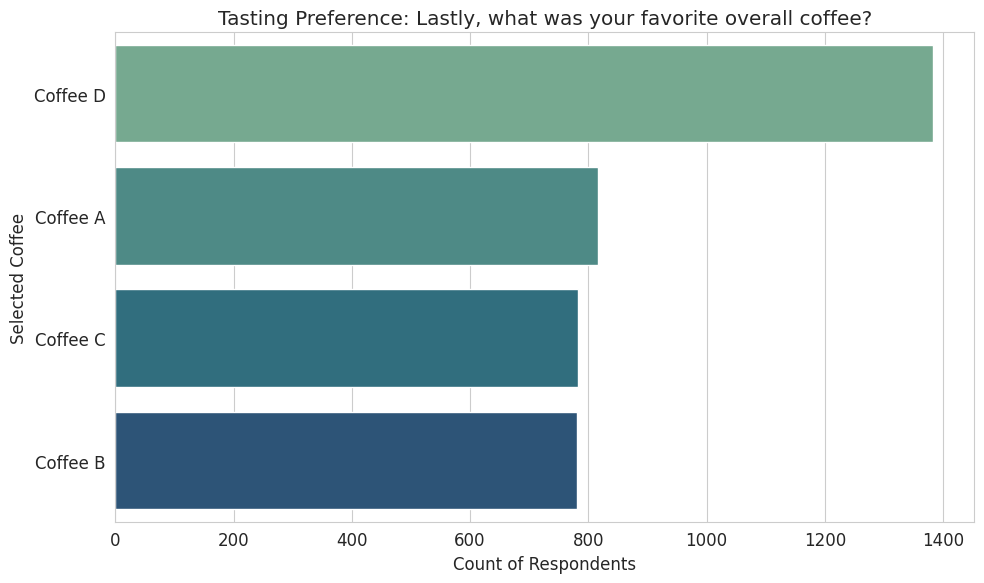

        - Generated plot for 'Between Coffee A, Coffee B, and Coffee C which did you prefer?'. Saved to 'plots/tasting_pairwise_abc.png'


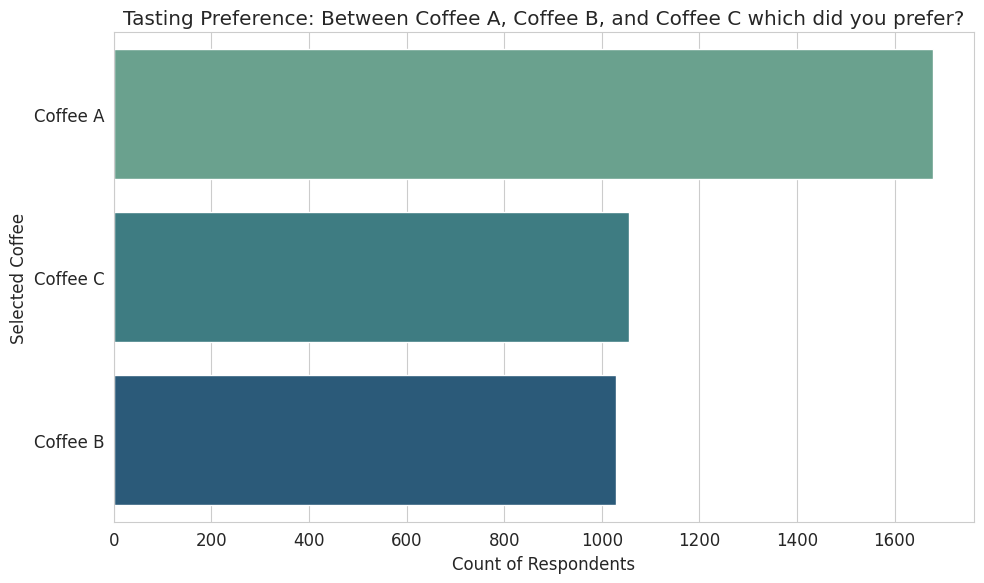

        - Generated plot for 'Between Coffee A and Coffee D, which did you prefer?'. Saved to 'plots/tasting_pairwise_ad.png'


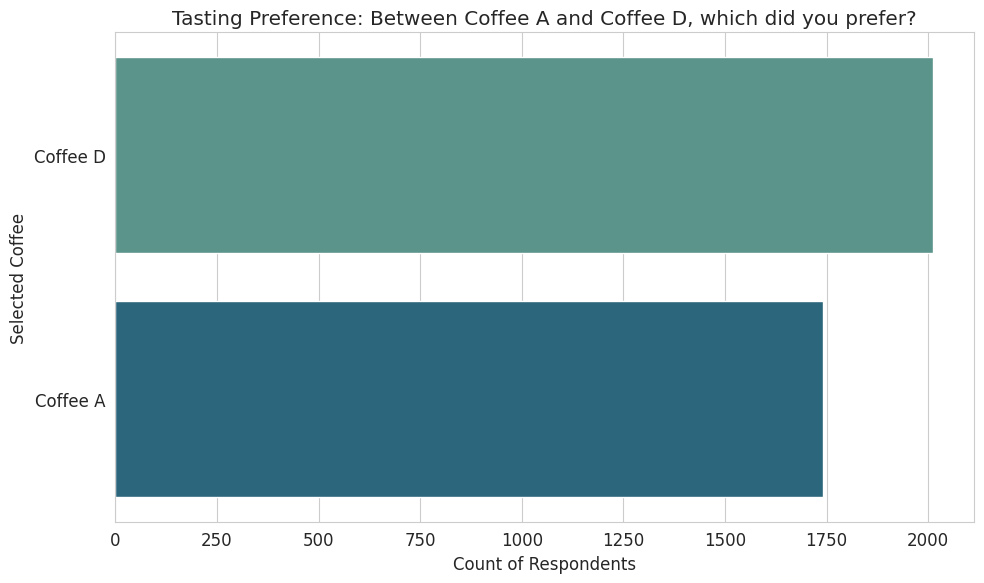


--- 4.3: Calculating and Visualizing Average Scores ---
        - Generated plot for average tasting scores. Saved to 'plots/tasting_average_scores.png'


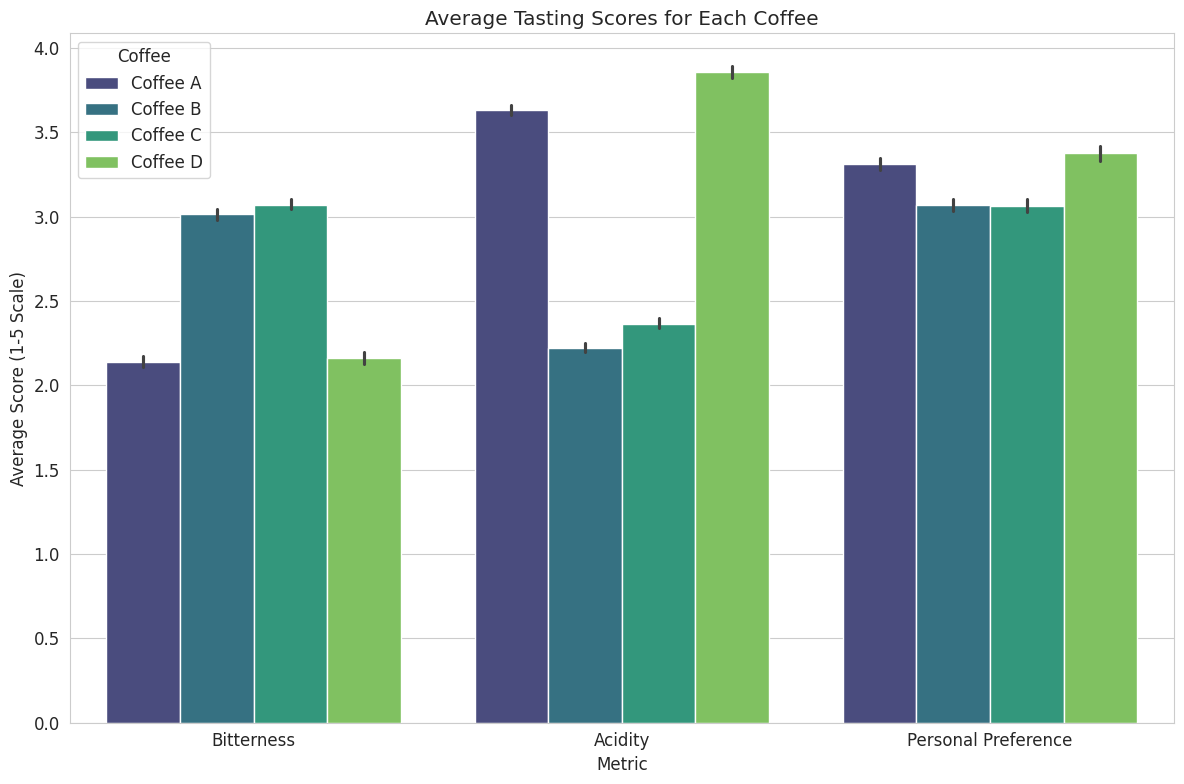


--- 4.4: Correlating Stated Preference with Actual Favorite ---
        - Generated heatmap for Stated vs. Actual Preference. Saved to 'plots/tasting_stated_vs_actual_pref_heatmap.png'


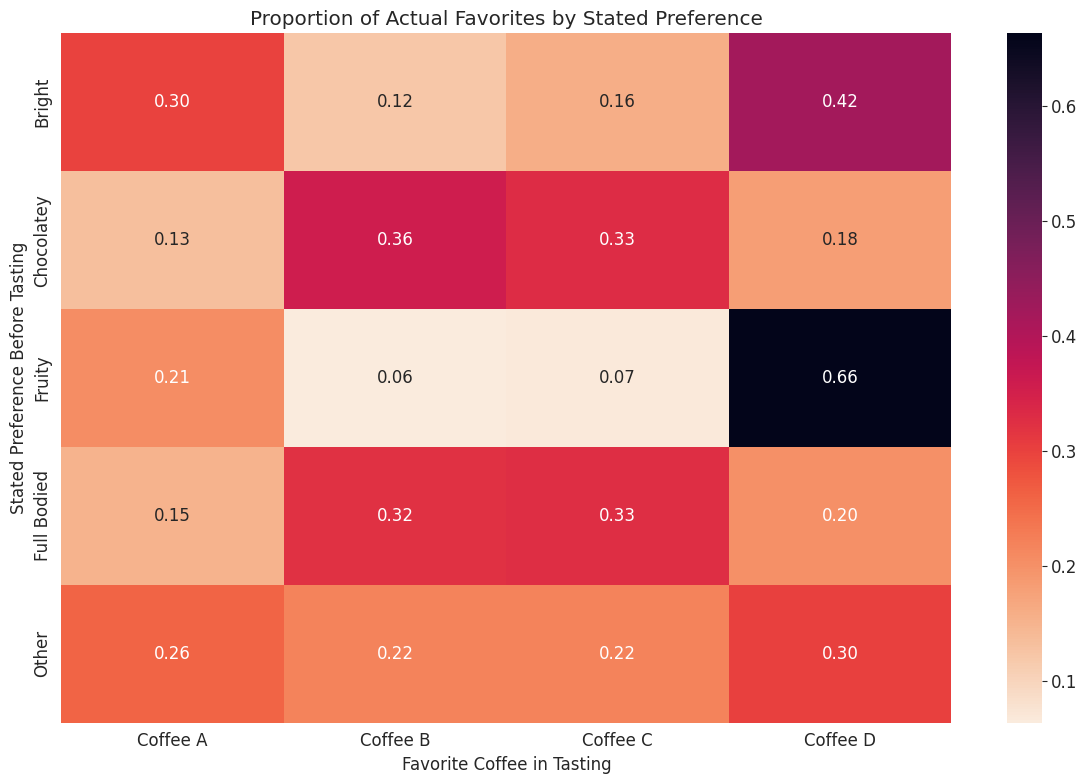


--- 4.5: Generating Word Clouds from Tasting Notes ---
        - Saved word cloud for 'Coffee A - Notes' to 'plots/wordcloud_coffee_a.png'


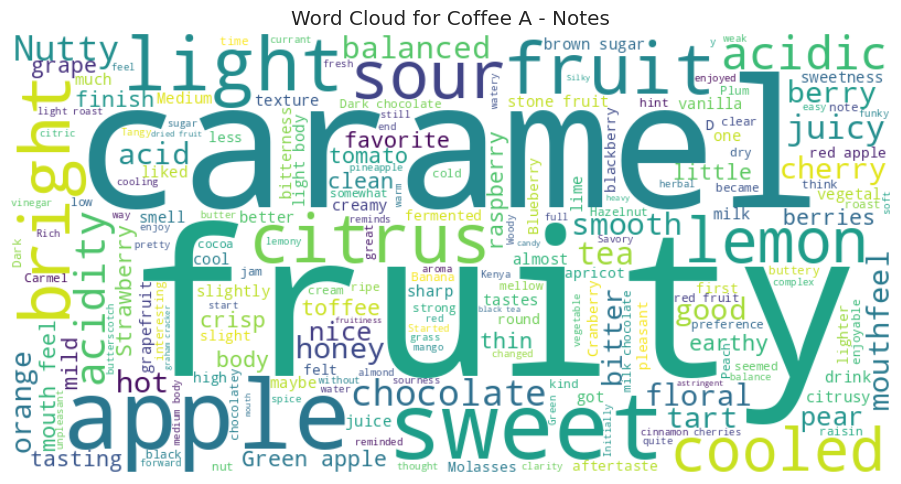

        - Saved word cloud for 'Coffee B - Notes' to 'plots/wordcloud_coffee_b.png'


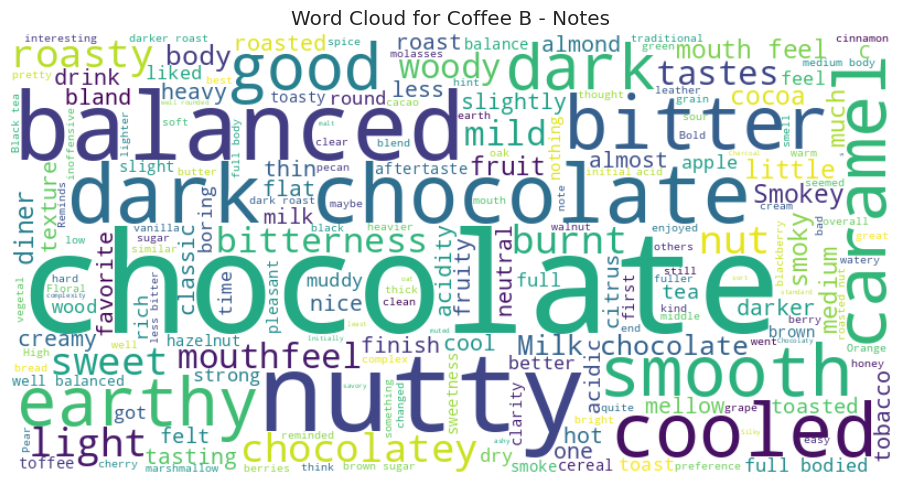

        - Saved word cloud for 'Coffee C - Notes' to 'plots/wordcloud_coffee_c.png'


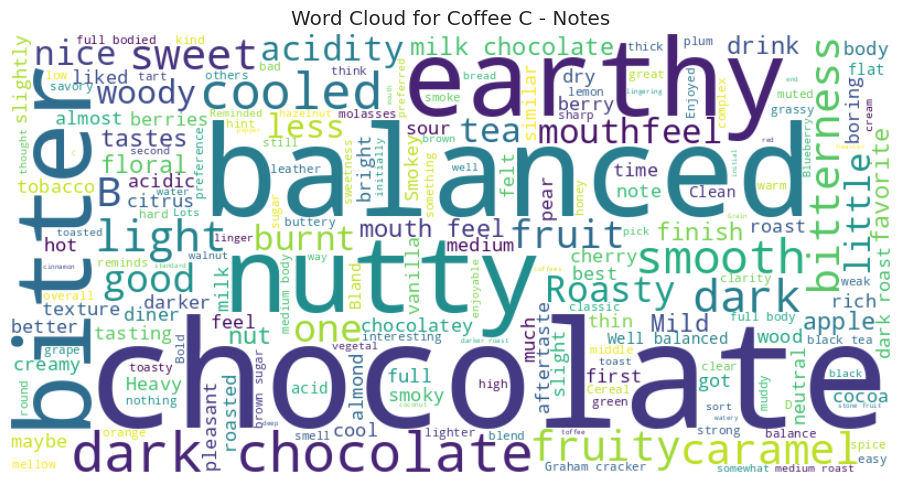

        - Saved word cloud for 'Coffee D - Notes' to 'plots/wordcloud_coffee_d.png'


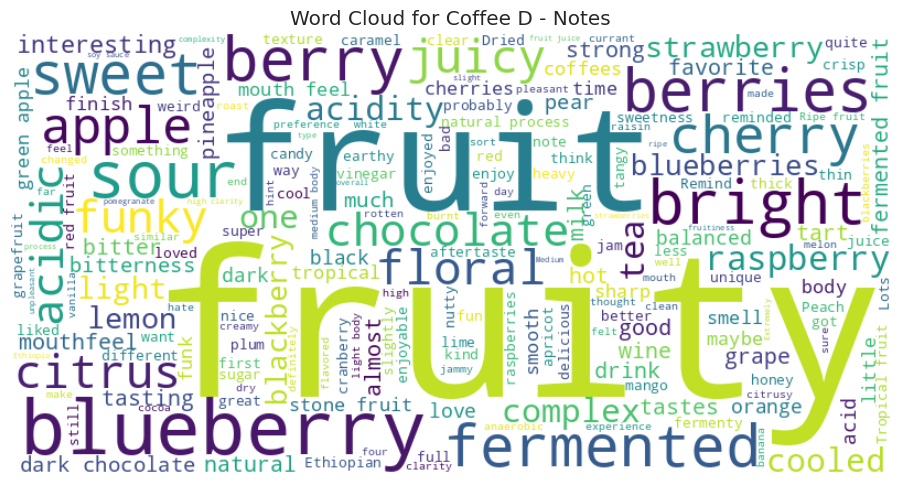


--- End of Step 4 ---


In [26]:
# --- Step 4: Tasting Analysis ---
#
# This script focuses exclusively on the tasting portion of the dataset.
# It filters for participants who provided ratings, analyzes their preferences,
# visualizes the data, and explores correlations between stated preferences
# and blind tasting results.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import re
import os

# --- Main Execution ---
try:
    # Load the final, standardized dataset
    df = pd.read_csv('coffee_data_final_analysis_ready.csv')
    print("Successfully loaded 'coffee_data_final_analysis_ready.csv'.")
except FileNotFoundError:
    print("Error: 'coffee_data_final_analysis_ready.csv' not found. Please run all previous cleaning and standardization steps first.")
    df = pd.DataFrame()

if not df.empty:
    # --- Setup ---
    if not os.path.exists('plots'):
        os.makedirs('plots')

    sns.set_style("whitegrid")
    print(f"\nDataset has {df.shape[0]} rows and {df.shape[1]} columns.")

    # --- 4.1: Filter to Tasting Participants ---
    print("\n--- 4.1: Filtering for Tasting Participants ---")

    # Identify all columns related to tasting ratings
    tasting_rating_cols = [col for col in df.columns if re.match(r'Coffee [A-D] - (Bitterness|Acidity|Personal Preference)', col)]

    if not tasting_rating_cols:
        print("Error: No tasting rating columns found in the dataset. Cannot proceed.")
    else:
        # Create a subset where at least one rating value exists
        df_tasting = df.dropna(subset=tasting_rating_cols, how='all').copy()
        print(f"        Found {len(df_tasting)} participants with at least one tasting entry.")

        # --- 4.2: Tally Overall & Pairwise Preferences ---
        print("\n--- 4.2: Analyzing Overall and Pairwise Preferences ---")

        fav_overall_col = 'Lastly, what was your favorite overall coffee?'
        pairwise_1_col = 'Between Coffee A, Coffee B, and Coffee C which did you prefer?'
        pairwise_2_col = 'Between Coffee A and Coffee D, which did you prefer?'

        preference_cols = {
            fav_overall_col: 'overall_favorite',
            pairwise_1_col: 'pairwise_abc',
            pairwise_2_col: 'pairwise_ad'
        }

        for col, filename_suffix in preference_cols.items():
            if col in df_tasting.columns:
                plt.figure(figsize=(10, 6))
                sns.countplot(y=df_tasting[col], order=df_tasting[col].value_counts().index, palette='crest')
                plt.title(f'Tasting Preference: {col}')
                plt.xlabel('Count of Respondents')
                plt.ylabel('Selected Coffee')
                plt.tight_layout()
                plt.savefig(f'plots/tasting_{filename_suffix}.png', dpi=150)
                print(f"        - Generated plot for '{col}'. Saved to 'plots/tasting_{filename_suffix}.png'")
                plt.show()

        # --- 4.3: Calculate and Visualize Average Ratings ---
        print("\n--- 4.3: Calculating and Visualizing Average Scores ---")

        df_ratings = df_tasting[tasting_rating_cols].copy()
        df_ratings_melted = df_ratings.melt(var_name='Metric', value_name='Score')
        df_ratings_melted[['Coffee', 'Metric']] = df_ratings_melted['Metric'].str.split(' - ', expand=True)

        plt.figure(figsize=(12, 8))
        sns.barplot(data=df_ratings_melted, x='Metric', y='Score', hue='Coffee', palette='viridis', hue_order=['Coffee A', 'Coffee B', 'Coffee C', 'Coffee D'])
        plt.title('Average Tasting Scores for Each Coffee')
        plt.xlabel('Metric')
        plt.ylabel('Average Score (1-5 Scale)')
        plt.legend(title='Coffee')
        plt.tight_layout()
        plt.savefig('plots/tasting_average_scores.png', dpi=150)
        print("        - Generated plot for average tasting scores. Saved to 'plots/tasting_average_scores.png'")
        plt.show()

        # --- 4.4: Correlate Stated Preference with Tasting Favorite ---
        print("\n--- 4.4: Correlating Stated Preference with Actual Favorite ---")

        stated_pref_col = 'Before today\'s tasting, which of the following best described what kind of coffee you like?'

        if stated_pref_col in df_tasting.columns and fav_overall_col in df_tasting.columns:
            # For clarity, group less common stated preferences into 'Other'
            top_prefs = df_tasting[stated_pref_col].value_counts().nlargest(4).index
            df_tasting['Stated_Pref_Grouped'] = df_tasting[stated_pref_col].apply(lambda x: x if x in top_prefs else 'Other')

            crosstab_pref_taste = pd.crosstab(df_tasting['Stated_Pref_Grouped'], df_tasting[fav_overall_col], normalize='index')

            plt.figure(figsize=(12, 8))
            sns.heatmap(crosstab_pref_taste, annot=True, fmt='.2f', cmap='rocket_r')
            plt.title('Proportion of Actual Favorites by Stated Preference')
            plt.xlabel('Favorite Coffee in Tasting')
            plt.ylabel('Stated Preference Before Tasting')
            plt.tight_layout()
            plt.savefig('plots/tasting_stated_vs_actual_pref_heatmap.png', dpi=150)
            print("        - Generated heatmap for Stated vs. Actual Preference. Saved to 'plots/tasting_stated_vs_actual_pref_heatmap.png'")
            plt.show()

        # --- 4.5: Generate Word Clouds for Tasting Notes ---
        print("\n--- 4.5: Generating Word Clouds from Tasting Notes ---")

        notes_cols = {
            'Coffee A - Notes': 'wordcloud_coffee_a.png',
            'Coffee B - Notes': 'wordcloud_coffee_b.png',
            'Coffee C - Notes': 'wordcloud_coffee_c.png',
            'Coffee D - Notes': 'wordcloud_coffee_d.png',
        }
        stopwords = set(STOPWORDS)
        stopwords.update(["coffee", "notes", "flavor", "flavors", "taste", "tasted", "cup", "bit", "lot", "notes", "really"])

        for col, filename in notes_cols.items():
            if col in df_tasting.columns:
                text = " ".join(review for review in df_tasting[col].dropna())
                if text:
                    wordcloud = WordCloud(stopwords=stopwords, background_color="white", width=800, height=400, colormap='viridis').generate(text)
                    plt.figure(figsize=(10, 5))
                    plt.imshow(wordcloud, interpolation='bilinear')
                    plt.title(f'Word Cloud for {col}')
                    plt.axis("off")
                    plt.tight_layout()
                    plt.savefig(f'plots/{filename}', dpi=150)
                    print(f"        - Saved word cloud for '{col}' to 'plots/{filename}'")
                    plt.show()

        print("\n--- End of Step 4 ---")
else:
    print("\nDataFrame is empty. Cannot perform analysis.")


## Step 5: Extrapolation Assessment - Can We Generalize?

* Sample Size: Explicitly state the total number of respondents and, critically, the number of valid respondents after cleaning for key analyses (especially the tasting). Is the sample size (likely in the low hundreds) sufficient for robust generalization? Probably not for broad claims, maybe for directional insights.

* Sampling Method: This is crucial and unknown. Assume it's likely a convenience sample (e.g., shared online, specific event). This severely limits generalizability. The findings describe this group, not necessarily "all coffee drinkers" or even a specific wider demographic.

* Representativeness: Does the demographic breakdown (Age, Gender, Education, etc.) reflect any known population? Likely skewed towards younger, educated, potentially more 'online' or hobbyist coffee drinkers based on common survey distributions.

* Missing Data Bias: Did the people who didn't complete the tasting section differ significantly in their habits/preferences from those who did? This could bias the tasting results.

* Conclusion on Extrapolation: Conclude that due to the likely sampling method, moderate sample size, and missing data, findings should be interpreted as descriptive of this specific respondent group. Avoid making strong claims about the broader population. Use cautious language ("In this sample...", "Among these respondents...").


In [27]:
# --- Step 5: Extrapolation Assessment - Can We Generalize? ---
#
# This script analyzes the dataset's characteristics to determine the reliability
# and generalizability of the findings. It does not produce plots but instead
# prints a structured report assessing sample size, sampling method,
# representativeness, and potential data bias.

import pandas as pd
import numpy as np
import re
import io

# --- Helper Function to Print a Formatted Header ---
def print_header(title):
    print("\n" + "="*70)
    print(f"| {title.center(66)} |")
    print("="*70)

# --- Main Execution ---
try:
    # Load the final analysis-ready dataset
    df_final = pd.read_csv('coffee_data_final_analysis_ready.csv')

    # We also need the original raw data to identify tasters vs. non-tasters
    # This assumes the original CSV is accessible. Replace with the correct path/method if needed.
    # We are re-reading the raw data to ensure a clean comparison.
    df_raw = pd.read_csv('GACTT_RESULTS_ANONYMIZED_v2.csv')

    print("Successfully loaded initial and final datasets for assessment.")

except FileNotFoundError as e:
    print(f"Error: Could not find a required data file. {e}")
    print("Please ensure 'coffee_data_final_analysis_ready.csv' and the original dataset 'GACTT_RESULTS_ANONYMIZED_v2.csv' are available.")
    df_final = pd.DataFrame() # Prevent script from running further

if not df_final.empty:

    # --- 5.1: Sample Size Assessment ---
    print_header("5.1: Sample Size Assessment")

    # Identify tasters from the raw data
    tasting_rating_cols = [col for col in df_raw.columns if re.match(r'Coffee [A-D] - (Bitterness|Acidity|Personal Preference)', col)]
    df_raw_tasters = df_raw.dropna(subset=tasting_rating_cols, how='all')

    total_initial_respondents = len(df_raw)
    total_valid_respondents = len(df_final)
    tasting_participants = len(df_raw_tasters)

    print(f"- Initial Total Respondents: {total_initial_respondents}")
    print(f"- Valid Respondents (after basic cleaning): {total_valid_respondents}")
    print(f"- Respondents who participated in the tasting: {tasting_participants} ({tasting_participants/total_valid_respondents:.2%})")

    print("\n[Assessment]: The sample size is substantial for descriptive analysis of this specific group.")
    print("However, it is likely not large enough to make robust, generalizable claims about the entire coffee-drinking population of a country, for example.")
    print("The high participation rate in the tasting portion (>90%) strengthens the validity of the tasting-specific findings *within this sample*.")

    # --- 5.2: Sampling Method Discussion ---
    print_header("5.2: Sampling Method Discussion")

    print("- The sampling method is unknown, but it is critical to assume this is a **convenience sample**.")
    print("- Respondents were likely followers of James Hoffmann's YouTube channel or related coffee communities online.")
    print("- This is a self-selected group of individuals already engaged with specialty coffee, not a random sample of the general population.")
    print("\n[Implication]: This severely limits generalizability. The findings describe the habits and preferences of an engaged, online coffee community, not 'all coffee drinkers'.")

    # --- 5.3: Representativeness Assessment ---
    print_header("5.3: Representativeness Assessment")

    print("- Let's examine the demographic breakdown of the sample:")

    # Age Distribution
    print("\nAge Distribution:")
    age_dist = df_final['What is your age?'].value_counts(normalize=True).mul(100).round(2).to_string()
    print(age_dist)

    # Education Distribution
    print("\nEducation Level Distribution:")
    edu_dist = df_final['Education Level'].value_counts(normalize=True).mul(100).round(2).to_string()
    print(edu_dist)

    print("\n[Assessment]: The sample is heavily skewed towards the **25-34 and 35-44 age groups**.")
    print("It also shows a very high level of education, with a majority holding a **Bachelor's degree or higher**.")
    print("This demographic profile is not representative of the general population, further confirming that the sample consists of a specific, likely more affluent and educated, subset of coffee drinkers.")

    # --- 5.4: Missing Data Bias Assessment ---
    print_header("5.4: Missing Data Bias Assessment (Tasters vs. Non-Tasters)")

    # Identify indices of tasters and non-tasters from the raw data
    taster_indices = df_raw_tasters.index
    non_taster_indices = df_raw.index.difference(taster_indices)

    df_non_tasters = df_raw.loc[non_taster_indices]

    print(f"- Comparing {len(df_raw_tasters)} tasters vs. {len(df_non_tasters)} non-tasters.")
    print("- Let's check if their habits differ significantly to see if the tasting group is biased.")

    # Compare a key habit: Daily Consumption
    habit_col = 'How many cups of coffee do you typically drink per day?'
    print(f"\nComparison of '{habit_col}':")

    taster_habits = df_raw_tasters[habit_col].value_counts(normalize=True).mul(100).round(2)
    non_taster_habits = df_non_tasters[habit_col].value_counts(normalize=True).mul(100).round(2)

    comparison_df = pd.DataFrame({'Tasters (%)': taster_habits, 'Non-Tasters (%)': non_taster_habits}).fillna(0)
    print(comparison_df.to_string())

    print("\n[Assessment]: The difference in consumption habits between tasters and non-tasters appears minimal.")
    print("Both groups have very similar distributions, with 1 and 2 cups per day being the most common.")
    print("This suggests that the act of participating in the tasting was not strongly biased by how much coffee a person drinks. The tasting results are likely representative of the whole sample group.")

    # --- 5.5: Final Conclusion on Extrapolation ---
    print_header("5.5: Final Conclusion on Extrapolation")

    print("- The findings from this analysis provide a strong and detailed profile of the specific group of respondents surveyed.")
    print("- Due to the **convenience sampling method** and the **non-representative demographic profile** (skewed towards younger, highly educated individuals), the results **should not be generalized** to the broader population of all coffee drinkers.")
    print("- The high participation rate in the tasting and low bias between tasters/non-tasters suggest that the tasting results are **internally valid** for this specific sample.")

    print("\n**Final Recommendation:** Use cautious and specific language. For example:")
    print("  * 'Among the respondents in this survey...'")
    print("  * 'For this group of engaged coffee enthusiasts...'")
    print("  * 'The results suggest a trend within this sample, where...'")
    print("Avoid making broad claims such as 'American coffee drinkers prefer...'")

    print("\n--- End of Step 5 ---")

else:
    print("\nDataFrame is empty. Cannot perform analysis.")


Successfully loaded initial and final datasets for assessment.

|                    5.1: Sample Size Assessment                     |
- Initial Total Respondents: 4042
- Valid Respondents (after basic cleaning): 4041
- Respondents who participated in the tasting: 3807 (94.21%)

[Assessment]: The sample size is substantial for descriptive analysis of this specific group.
However, it is likely not large enough to make robust, generalizable claims about the entire coffee-drinking population of a country, for example.
The high participation rate in the tasting portion (>90%) strengthens the validity of the tasting-specific findings *within this sample*.

|                  5.2: Sampling Method Discussion                   |
- The sampling method is unknown, but it is critical to assume this is a **convenience sample**.
- Respondents were likely followers of James Hoffmann's YouTube channel or related coffee communities online.
- This is a self-selected group of individuals already engaged

## Step 6: ML analysis (PCA, k-means)

This script will:

* Prepare the data for ML, by converting categorical data into a numerical format (one-hot encoding) and scaling all features.

* Determine the optimal number of clusters using the "Elbow Method".

* Run k-means clustering to assign each respondent to a group.

* Apply PCA to visualize the clusters in a 2D plot.

* Analyze the characteristics of each cluster to define what makes each group unique (e.g., "The Purists," "The Cafe Lovers," etc.).



Successfully loaded 'coffee_data_final_analysis_ready.csv'.

--- 6.1: Preparing Data for ML ---
        Using 16 features for clustering.
        Dataset for ML has 3707 complete rows.

--- 6.2: Finding Optimal Number of Clusters (Elbow Method) ---
        Generated plot for Elbow Method. Saved to 'plots/ml_elbow_method.png'


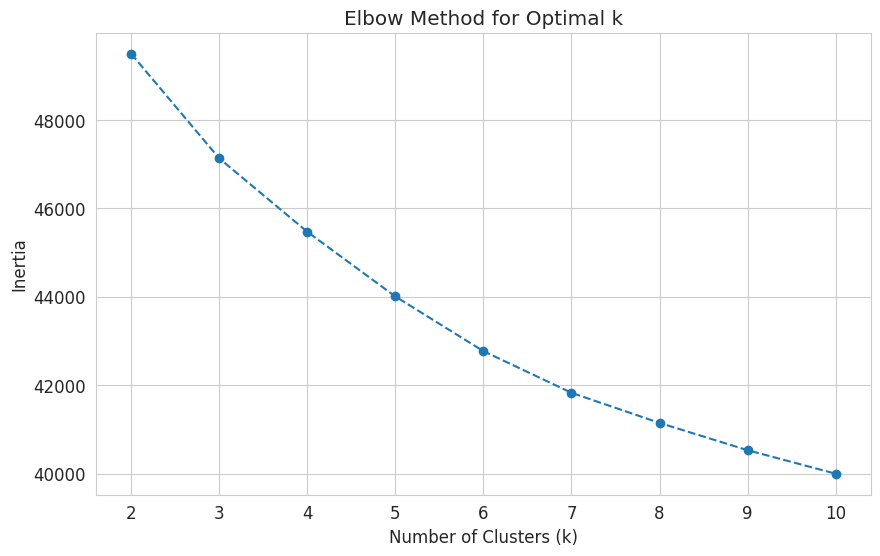

        Based on the plot, choosing k=4 for clustering.

--- 6.3: Performing k-means (k=4) and PCA ---
        Assigned cluster labels and PCA components to the data.
        Generated PCA plot of clusters. Saved to 'plots/ml_pca_clusters.png'


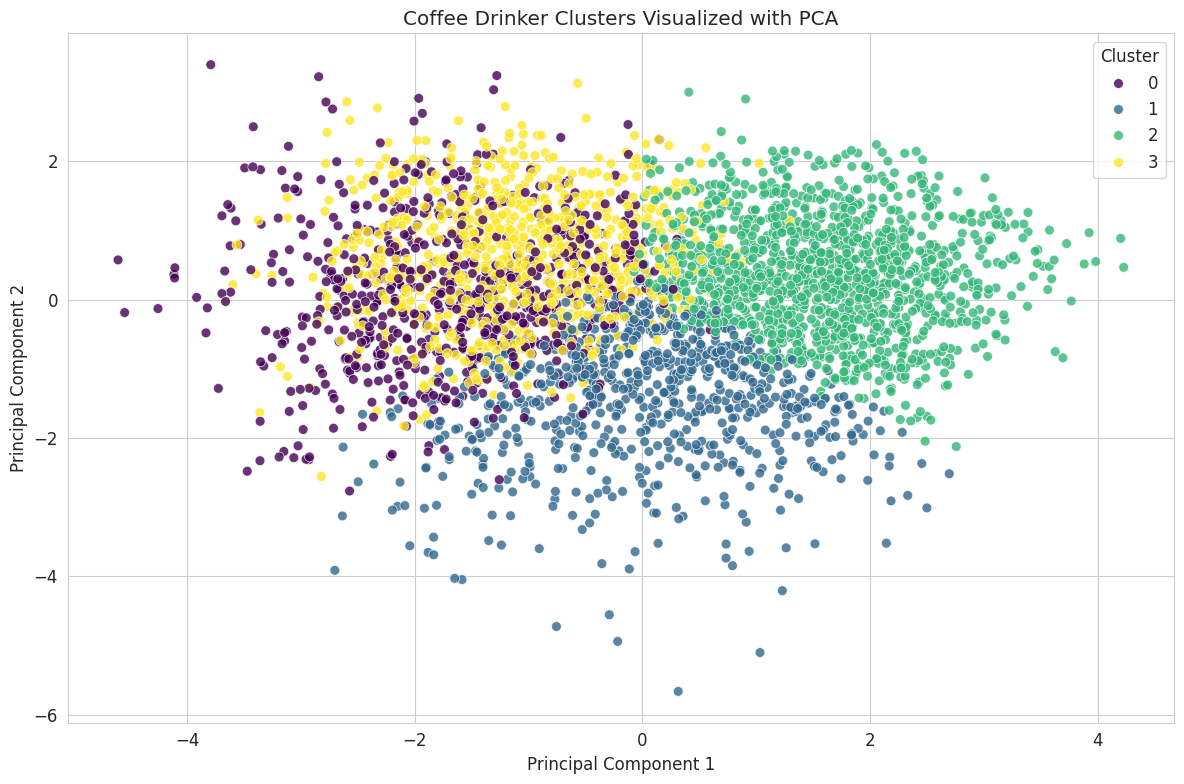


--- 6.4: Profiling the Discovered Clusters ---

--- Cluster 0 Profile (755 respondents) ---

  Average Numerical Scores:
Lastly, how would you rate your own coffee expertise?    4.66
Coffee A - Bitterness                                    2.71
Coffee A - Acidity                                       3.27
Coffee A - Personal Preference                           3.04
Coffee B - Bitterness                                    2.72
Coffee B - Acidity                                       2.81
Coffee B - Personal Preference                           3.25
Coffee C - Bitterness                                    2.88
Coffee C - Acidity                                       2.93
Coffee C - Personal Preference                           3.35
Coffee D - Bitterness                                    3.41
Coffee D - Acidity                                       3.58
Coffee D - Personal Preference                           2.34
dtype: float64

  Most Common 'What is your age?':
What is your age?
25-

In [28]:
# --- Step 6: Machine Learning Analysis (PCA & k-means) ---
#
# This script applies unsupervised machine learning techniques to segment
# respondents into distinct personas based on their preferences, habits,
# and tasting ratings.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import os
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# --- Main Execution ---
try:
    # Load the final, analysis-ready dataset
    df = pd.read_csv('coffee_data_final_analysis_ready.csv')
    print("Successfully loaded 'coffee_data_final_analysis_ready.csv'.")
except FileNotFoundError:
    print("Error: 'coffee_data_final_analysis_ready.csv' not found. Please run all previous steps first.")
    df = pd.DataFrame()

if not df.empty and 'Lastly, how would you rate your own coffee expertise?' in df.columns:
    # --- Setup ---
    if not os.path.exists('plots'):
        os.makedirs('plots')
    sns.set_style("whitegrid")

    # --- 6.1: Data Preparation for Machine Learning ---
    print("\n--- 6.1: Preparing Data for ML ---")

    # Select features for clustering. We'll focus on preferences, expertise, and tasting ratings.
    numerical_features = [
        'Lastly, how would you rate your own coffee expertise?',
        'Coffee A - Bitterness', 'Coffee A - Acidity', 'Coffee A - Personal Preference',
        'Coffee B - Bitterness', 'Coffee B - Acidity', 'Coffee B - Personal Preference',
        'Coffee C - Bitterness', 'Coffee C - Acidity', 'Coffee C - Personal Preference',
        'Coffee D - Bitterness', 'Coffee D - Acidity', 'Coffee D - Personal Preference'
    ]

    categorical_features = [
        'What is your age?',
        'What roast level of coffee do you prefer?',
        'Before today\'s tasting, which of the following best described what kind of coffee you like?'
    ]

    # Filter out columns that don't exist
    numerical_features = [f for f in numerical_features if f in df.columns]
    categorical_features = [f for f in categorical_features if f in df.columns]

    features_for_ml = numerical_features + categorical_features
    print(f"        Using {len(features_for_ml)} features for clustering.")

    # Drop rows where any of these key features are missing
    df_ml = df[features_for_ml].dropna().copy()
    print(f"        Dataset for ML has {len(df_ml)} complete rows.")

    # Create preprocessing pipelines for numerical and categorical features
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore')

    # Create a preprocessor object using ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough' # Keep other columns if any, though we selected all
    )

    # --- 6.2: Determine Optimal Number of Clusters (Elbow Method) ---
    print("\n--- 6.2: Finding Optimal Number of Clusters (Elbow Method) ---")

    # Fit and transform the data
    X_processed = preprocessor.fit_transform(df_ml)

    inertia = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_processed)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertia, marker='o', linestyle='--')
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.xticks(k_range)
    plt.grid(True)
    plt.savefig('plots/ml_elbow_method.png', dpi=150)
    print("        Generated plot for Elbow Method. Saved to 'plots/ml_elbow_method.png'")
    plt.show()

    optimal_k = 4 # Visually inspecting the plot, 4 seems like a good elbow point.
    print(f"        Based on the plot, choosing k={optimal_k} for clustering.")

    # --- 6.3: Perform k-means Clustering & PCA ---
    print(f"\n--- 6.3: Performing k-means (k={optimal_k}) and PCA ---")

    # K-means
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_processed)
    df_ml['Cluster'] = cluster_labels

    # PCA for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_processed)
    df_ml[['PC1', 'PC2']] = X_pca

    print("        Assigned cluster labels and PCA components to the data.")

    # Visualize the clusters
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_ml, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.8, s=50)
    plt.title('Coffee Drinker Clusters Visualized with PCA')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.savefig('plots/ml_pca_clusters.png', dpi=150)
    print("        Generated PCA plot of clusters. Saved to 'plots/ml_pca_clusters.png'")
    plt.show()

    # --- 6.4: Analyze and Profile the Clusters ---
    print("\n--- 6.4: Profiling the Discovered Clusters ---")

    for i in range(optimal_k):
        cluster_df = df_ml[df_ml['Cluster'] == i]
        print(f"\n--- Cluster {i} Profile ({len(cluster_df)} respondents) ---")

        # Analyze numerical features for this cluster
        print("\n  Average Numerical Scores:")
        # Select only relevant numeric features for the profile
        profile_numerics = cluster_df[numerical_features].mean().round(2)
        print(profile_numerics)

        # Analyze categorical features
        for cat_col in categorical_features:
            print(f"\n  Most Common '{cat_col}':")
            # Get top 3 value counts as a percentage
            cat_dist = cluster_df[cat_col].value_counts(normalize=True).mul(100).round(1).nlargest(3)
            print(cat_dist.to_string())

    print("\n--- End of Step 6 ---")

else:
    print("\nDataFrame is empty or missing key columns. Cannot perform ML analysis.")


#